In [11]:
# loading packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss
import shap

In [12]:
# machine learning regression
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, StratifiedKFold, KFold, RandomizedSearchCV
from sklearn.preprocessing import PolynomialFeatures , MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, BayesianRidge 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  , mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
from sklearn.cluster import KMeans
from sklearn.base import clone

from xgboost import XGBRegressor , XGBClassifier
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb

In [13]:
#=========================================================
#  Load dataset and checking nan
#=========================================================

df_original = pd.read_csv("C:\\Github\\Coral_Bleaching_Predictor\\Data\\dataset.csv" , na_values=['nd']) # old data
print(f"total number of rows and columns in the dataset: {len(df_original.columns) + 1} columns, {len(df_original) + 1} rows")


# Grouping years into decodes
def Grouping_date_to_year(df):
    #Changing date to year
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Year'] = df['Date'].dt.year # New columns with only year 
    
    year_counts = df.groupby(['Year']).size()
    print(year_counts)
    

    return df

df_Grouping_year = Grouping_date_to_year(df_original)

# Check NAN Data and by what percentage
def nan_check(data):
    total = data.isnull().sum().sort_values(ascending=False)
    percent_1 = data.isnull().sum()/data.isnull().count()*100
    percent_2 = (np.round(percent_1, 1)).sort_values(ascending=False)
    missing_data = pd.concat([total, percent_2], axis=1, keys=['Total', '%'])
    return missing_data

Missing  = nan_check(df_Grouping_year)
Missing

total number of rows and columns in the dataset: 49 columns, 9666 rows
Year
1998      5
2000      2
2001      3
2002     63
2003    599
2004    731
2005    700
2006    850
2007    643
2008    692
2009    721
2010    538
2011    533
2012    563
2013    626
2014    600
2015    615
2016    619
2017    562
dtype: int64


,Total,%
City_Town_3,8728,90.3
City_Town_2,4943,51.1
City_Town,437,4.5
State_Island_Province,36,0.4
SSTA_Minimum,12,0.1
SSTA_FrequencyMax,5,0.1
SSTA_Standard_Deviation,5,0.1
TSA_Maximum,5,0.1
SSTA_Maximum,5,0.1
SSTA_Frequency,5,0.1


In [14]:
#=================================================
# Function analysis variable for Cleaning data
#=================================================
def Columns_percent_missing(df,df_dtype, col):
    
    count_less = 0
    count_more = 0
    Index_more = []
    Index_less = []
    for_drop = []
    type_object = []
    type_number = []
    for idx, value in df[col].items():
        if value >= 0.4:
            count_more += 1
            Index_more.append(idx)
            for_drop.append(idx)
        elif value < 0.4:
            count_less += 1
            Index_less.append(idx)
            
    for i in df_dtype.columns:
        if df_dtype[i].dtype == 'object':
            type_object.append(i)
        else:
            type_number.append(i)

    print("\n")
    print(f"more than 0.4% : {count_more}")
    print(f"less than 0.4% : {count_less}")
    print(f"Name_of_moreNAN : {len(Index_more)} attribuue : {Index_more}")
    print(f"Name_of_lessNAN : {len(Index_less)} attribuue : {Index_less}")
    print(f"for_drop : {len(for_drop)} attribuue : {for_drop}")
    print(f"object type : {len(type_object)} attribue : {type_object}")
    print(f"number type : {len(type_number)} attribue : {type_number}")

    return for_drop , type_object
    
columns_drop, col_object = Columns_percent_missing(Missing, df_original, '%')
print("="*80)
print(">>>>>>>  Missing values more than 0.4% : Delete <<<<<<<<")
print("="*80)



more than 0.4% : 4
less than 0.4% : 45
Name_of_moreNAN : 4 attribuue : ['City_Town_3', 'City_Town_2', 'City_Town', 'State_Island_Province']
Name_of_lessNAN : 45 attribuue : ['SSTA_Minimum', 'SSTA_FrequencyMax', 'SSTA_Standard_Deviation', 'TSA_Maximum', 'SSTA_Maximum', 'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'SSTA_Mean', 'SSTA_FrequencyMean', 'Temperature_Kelvin_Standard_Deviation', 'SSTA_DHW', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA', 'SSTA', 'Temperature_Minimum', 'Temperature_Maximum', 'TSA_Minimum', 'Temperature_Mean', 'Temperature_Kelvin', 'TSA_Mean', 'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax', 'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation', 'TSA_DHWMax', 'TSA_DHWMean', 'TSA_Standard_Deviation', 'Windspeed', 'ClimSST', 'ID', 'Latitude_Degrees', 'Average_Bleaching', 'Depth', 'Date2', 'Date', 'Country_Name', 'Ecoregion', 'Realm', 'Ocean', 'Longitude_Degrees', 'Year']
for_drop : 4 attribuue : ['City

In [15]:
#=========================================
# Cleaning data
#=========================================
def Clean_data_paper(df, col_object, col_dont_need):
    
    # using data from 2003 to 2020
    df = df[df['Year'] > 2002]

    # Taking only SSTA > 0
    df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce') # แปลง ค่าของ SSTA เป็นตัวเลข เเละจัดการกับค่าที่ไม่สามารถเเปลงได้ด้วยการใช้ 'coerce' ซึ่งจะทำให้ค่าที่แปลงไม่ได้กลายเป็น NaN
    df = df[df['SSTA'] > 0] # เลือกเฉพาะคที่มีค่า SSTA มากกว่า 0 เเละ NaN จะถูกละทิ้งไปโดยอัตโนมัติ
    
    df_object = df.drop(columns=col_object) # ลบคอลัมน์ที่เป็น Object ออกเเละค่าที่ไม่จำเป็นออกไป
    df_dont_need = df_object.drop(columns=col_dont_need) # ลบคอลัมน์ที่ไม่จำเป็นออกไป

    df = df_dont_need.rename(columns={"Depth": "Depth_m", "Average_Bleaching": "Percent_Bleaching"}) # เปลี่ยนชื่อคอลัมน์ให้สั้นลง เเละเจข้าใจง่ายขึ้น

    #Transforming column datatypes
    df['ClimSST'] = pd.to_numeric(df['ClimSST'],errors='coerce')
    df['Percent_Bleaching'] = pd.to_numeric(df['Percent_Bleaching'],errors='coerce')
    
    return df

col_dont_need = ['ID', 'Date', 'Date2', 'SSTA_Mean']
df_Clean_already = Clean_data_paper(df_Grouping_year, col_object, col_dont_need)
df_Clean_already = df_Clean_already.ffill()
print("="*200)
print(f"{col_object} >>>>> {col_dont_need} : {len(col_object) + len(col_dont_need)} >>>>>>>> {len(df_original.columns) - len(col_object) - len(col_dont_need)}")
print(f"total number of rows and columns in the dataset: {len(df_Clean_already.columns)} columns, {len(df_Clean_already)} rows")
print("มีการเพิ่มคอลัมน์ Year ขึ้นมาเพื่อนำมาใช้ในการจัดกลุ่มข้อมูลตามปี")
print("="*200)

[] >>>>> ['ID', 'Date', 'Date2', 'SSTA_Mean'] : 4 >>>>>>>> 45
total number of rows and columns in the dataset: 45 columns, 6112 rows
มีการเพิ่มคอลัมน์ Year ขึ้นมาเพื่อนำมาใช้ในการจัดกลุ่มข้อมูลตามปี


## ***ตัวแปรที่เก็บ data เเละพร้อมใช้งานสำหรับการนำไปวิเคราะห์ df_Clean_already***

In [16]:
df_Clean_already

,Latitude_Degrees,Longitude_Degrees,Ocean,Realm,Ecoregion,Country_Name,State_Island_Province,City_Town,City_Town_2,City_Town_3,...,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Year
0,-20.899833,149.407722,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Keswick Island,NaN,NaN,...,-3.260,3.0,1.950,7.000000,1.0,3.52,1.360000,8.43,0.520000,2016
1,-20.893056,149.421000,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Keswick Island,NaN,NaN,...,-3.260,3.0,1.950,7.000000,1.0,3.52,1.360000,8.43,0.520000,2016
2,-20.745806,149.472056,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Wigton Island,Wigton Island Reef,NaN,...,-3.060,1.0,1.470,5.000000,1.0,1.51,1.230000,7.32,0.490000,2016
3,-20.737694,149.464944,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Wigton Island,Wigton Island Reef,NaN,...,-3.010,2.0,1.310,5.000000,1.0,2.36,0.970000,6.86,0.360000,2016
4,-20.259361,148.814583,Pacific,Central Indo-Pacific,Central and northern Great Barrier Reef,Australia,Queensland,Mount Rooper,Daydream Island,NaN,...,-3.230,4.0,1.720,7.000000,1.0,0.00,1.470000,9.84,0.560000,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9641,20.738889,107.058333,Pacific,Central Indo-Pacific,North Vietnam,Vietnam,Hai Phong,Cat Hai,Dao Cat Ba,Hon La,...,-5.255,0.0,1.645,7.333333,1.0,0.00,1.381667,11.57,0.446667,2003
9646,20.845833,107.177778,Pacific,Central Indo-Pacific,North Vietnam,Vietnam,Quang Ninh,Ha Long,Namieviet,Hon La,...,-5.080,0.0,2.180,11.000000,1.0,0.00,1.740000,12.00,0.640000,2003
9649,12.601722,53.817306,Red Sea,Western Indo-Pacific,Socotra Archipelago,Yemen,Socotra Governorate,Socotra Island,Chiemar,Hon La,...,-3.240,0.0,1.400,6.000000,0.0,0.00,1.710000,19.41,0.370000,2008
9663,15.701611,42.391806,Red Sea,Western Indo-Pacific,South Red Sea,Yemen,Al Hudaydah Governorate,Jazirat Antufash,Seaem,Hon La,...,-2.690,0.0,1.630,6.000000,1.0,0.00,1.330000,8.30,0.540000,2008


##

##

##

## Modeling and ablation study

Baseline (Paper ต้นฉบับ)
- M0   X1, X2, X3, X4, X5ต้นฉบับ — baseline เปรียบเทียบ
- M1   X1, X2, X3, X4ตัด X5 ออก → แสดงว่า X5 เป็น noise
- M7 X1, X2, X3, X4, X5, X6ทดสอบว่าถ้าไม่ตัด X5 แต่เพิ่ม X6 จะเป็นอย่างไร


Feature Addition (เพิ่ม X6)
- M2   X1, X2, X3, X4, X6เพิ่ม X6 เข้ามา → แสดง X6 มี predictive power


Feature Engineering (เพิ่ม Interaction Terms)
- M3   M2 + X1×X2เพิ่ม interaction ทีละตัว
- M4   M2 + X1×X3เพิ่ม interaction ทีละตัว
- M5   M2 + X1×X6เพิ่ม interaction ทีละตัว
- M6 ✅M2 + X1×X2 + X1×X3 + X1×X6Full model ของคุณ

In [17]:
def PLOTING_RESULT_ML(model, X_test, y_test, cl, name):

    y_pred = model.predict(X_test).ravel()
    y_test = np.array(y_test).ravel()

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        x=y_test,
        y=y_pred,
        alpha=0.5,
        color=cl,
        edgecolor='k'
    )

    # ideal line
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red',
        linestyle='--',
        lw=2
    )

    plt.title(f'Actual vs Predicted Percent Bleaching : {name}')
    plt.xlabel('Actual Bleaching (%)')
    plt.ylabel('Predicted Bleaching (%)')

    plt.grid(True, linestyle=':', alpha=0.6)

    plt.show()
   
#=========================================================================================================================================================#
def feature_importance(model, feature_names):
    
    importance = model.feature_importances_
    feature_names_importance = feature_names.columns
    
    df_importance = pd.DataFrame({
        'feature' : feature_names_importance,
        'importance' : importance
    }).sort_values(by='importance', ascending=False)
    
    return df_importance

In [18]:
def Cross_validarion_regression(X_train, y_train, model, n_splits=5):

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    oof_preds = np.zeros(len(X_train))

    models = []

    rmse_scores = []
    mae_scores = []
    r2_scores = []

    y_train = np.array(y_train).ravel()

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):

        print(f"\n===== Fold {fold+1} / {n_splits} =====")

        # split
        X_tr = X_train[train_idx]
        X_val = X_train[val_idx]

        y_tr = y_train[train_idx]
        y_val = y_train[val_idx]
        
        # train
        reg = clone(model) 
        reg.fit(X_tr, y_tr)

        # predict
        pred = reg.predict(X_val)

        # save OOF
        oof_preds[val_idx] = pred

        # metrics
        rmse = np.sqrt(mean_squared_error(y_val, pred))
        mae = mean_absolute_error(y_val, pred)
        r2 = r2_score(y_val, pred)

        rmse_scores.append(rmse)
        mae_scores.append(mae)
        r2_scores.append(r2)

        models.append(reg)

        print(f"Fold RMSE : {rmse:.4f}")
        print(f"Fold MAE  : {mae:.4f}")
        print(f"Fold R2   : {r2:.4f}")
        
    print("\n")
    print(f"Mean RMSE : {np.mean(rmse_scores):.4f}")
    print(f"Mean MAE  : {np.mean(mae_scores):.4f}")
    print(f"Mean R2   : {np.mean(r2_scores):.4f}")
    
    print("="*50)

    return (
        models,
        oof_preds,
        rmse_scores,
        mae_scores,
        r2_scores
    )
    
#==================================================================================================================================================================================#


def Hyperparameter_tunning(X_train, y_train, model=RandomForestRegressor(random_state=42)):
    rf = model

    param_rf = {
        "n_estimators": [200, 300, 500, 800],
        "max_depth": [10, 15, 20, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"]
    }

    # 2. RandomizedSearchCV ทำ CV บน train เท่านั้น
    search_rf = RandomizedSearchCV(
        rf,
        param_rf,
        n_iter=30,
        cv=5,              # 5-fold บน X_train
        scoring="r2",
        n_jobs=-1,
        verbose=2,
        random_state=42
    )
    
    search_rf.fit(X_train, y_train)
    
    return search_rf

In [19]:
def X_train_test_split(X, y, test_size=0.2, random_state=42):
    return train_test_split(X, y, test_size=test_size, random_state=random_state)


##

##

## model 0th : Baseline 5 feature --> RF (tunning hyperparameter)

In [20]:
feature_paper = ['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'Depth_m', 'SSTA']
feature_Baseline = df_Clean_already[feature_paper]
target_Baseline = df_Clean_already['Percent_Bleaching']

algo_baseline = [
    [RandomForestRegressor(max_features = 'log2', 
                           max_depth = 20, 
                           criterion = 'squared_error', 
                           n_estimators = 300, 
                           min_samples_leaf = 1,
                           min_samples_split=2,
                           random_state = 42), 'RandomForestRegressor_Baseline', 'green']
]

In [21]:
X_train_paper, X_test_paper, y_train_paper, y_test_paper = X_train_test_split(feature_Baseline.values, target_Baseline.values)

In [22]:
all_results_baseline = []

for model, model_name, color in algo_baseline:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Cross_validarion_regression(
        feature_Baseline.values,
        target_Baseline.values,
        model,
        n_splits=5
    )

    all_results_baseline.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_Baseline.values,
        y_test=target_Baseline.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_Baseline)
print("\nFeature Importance:")
print(feature_importance_df)


========== RandomForestRegressor_Baseline ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.4184
Fold MAE  : 3.3848
Fold R2   : 0.1772

===== Fold 2 / 5 =====


KeyboardInterrupt: 

In [ ]:
search_rf_model1th = Hyperparameter_tunning(X_train_paper, y_train_paper)

# 3. ประเมินบน test set จริงครั้งเดียวตอนสุดท้าย
best_model_Baseline = search_rf_model1th.best_estimator_
print("CV R²  :", search_rf_model1th.best_score_)
print("Test R²:", best_model_Baseline.score(X_test_paper, y_test_paper))
print("best parameters:", search_rf_model1th.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
CV R²  : 0.2863707424342296
Test R²: 0.17837010380464113
best parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}


##

##

## model 1th : Drop depth feature becuase depth it less more permutation

In [ ]:
import warnings
from sklearn.exceptions import DataConversionWarning
# -----------------------------
# ปิด warning
# -----------------------------
warnings.filterwarnings("ignore", category=DataConversionWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
factors_model2th = ['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'SSTA']
feature_model2th = df_Clean_already[factors_model2th]

algo_model2th = [
    [RandomForestRegressor(max_features = 'log2', 
                           max_depth = 20, 
                           criterion = 'squared_error', 
                           n_estimators = 300, 
                           min_samples_leaf = 1,
                           min_samples_split=2,
                           random_state = 42), 'RandomForestRegressor_Nodepth', 'green'],
    
    [lgb.LGBMRegressor(colsample_bytree=0.6, 
                       learning_rate=0.01, 
                       max_depth=-1, 
                       n_estimators=1000, 
                       num_leaves=50, 
                       subsample=1.0,
                       verbose=-1,
                       random_state=42), 'LGBMRegressor_Nodepth' , 'green'],
    
    [XGBRegressor(colsample_bytree=0.6, 
                  learning_rate=0.01, 
                  max_depth=5, 
                  min_child_weight=3, 
                  n_estimators=500, 
                  subsample=0.8, 
                  gamma=0.2,
                  verbosity=0,
                  random_state=42), 'XGBRegressor_Nodepth' , 'orange']

]

In [ ]:
X_train_model2th, X_test_model2th, y_train_model2th, y_test_model2th = X_train_test_split(feature_model2th.values, target_Baseline.values)


========== RandomForestRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.3586
Fold MAE  : 3.2356
Fold R2   : 0.1888

===== Fold 2 / 5 =====
Fold RMSE : 8.2364
Fold MAE  : 3.3517
Fold R2   : 0.3313

===== Fold 3 / 5 =====
Fold RMSE : 7.9681
Fold MAE  : 3.1392
Fold R2   : 0.3568

===== Fold 4 / 5 =====
Fold RMSE : 7.8323
Fold MAE  : 3.0704
Fold R2   : 0.2939

===== Fold 5 / 5 =====
Fold RMSE : 7.4271
Fold MAE  : 3.1439
Fold R2   : 0.3927


Mean RMSE : 7.9645
Mean MAE  : 3.1882
Mean R2   : 0.3127


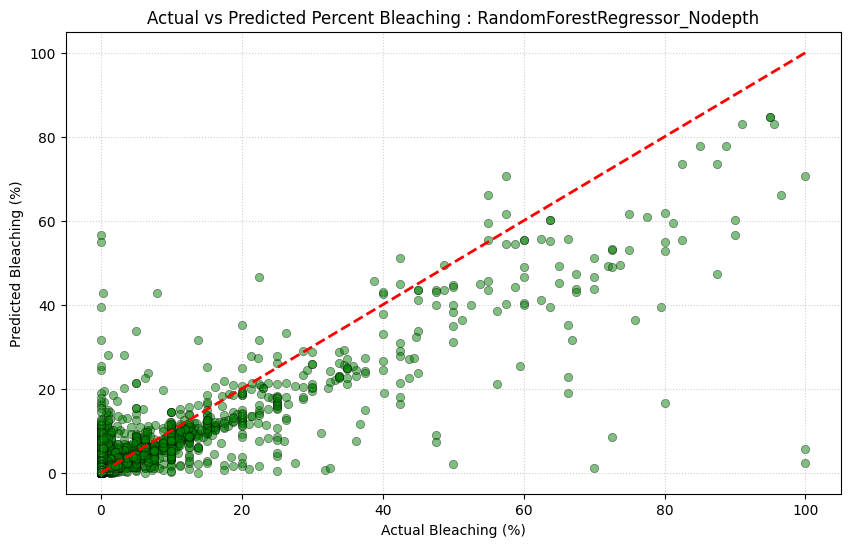


========== LGBMRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.8515
Fold MAE  : 3.8836
Fold R2   : 0.0903

===== Fold 2 / 5 =====
Fold RMSE : 8.6290
Fold MAE  : 3.8503
Fold R2   : 0.2660

===== Fold 3 / 5 =====
Fold RMSE : 8.4957
Fold MAE  : 3.6987
Fold R2   : 0.2688

===== Fold 4 / 5 =====
Fold RMSE : 8.4051
Fold MAE  : 3.7732
Fold R2   : 0.1868

===== Fold 5 / 5 =====
Fold RMSE : 8.0805
Fold MAE  : 3.7028
Fold R2   : 0.2811


Mean RMSE : 8.4924
Mean MAE  : 3.7817
Mean R2   : 0.2186


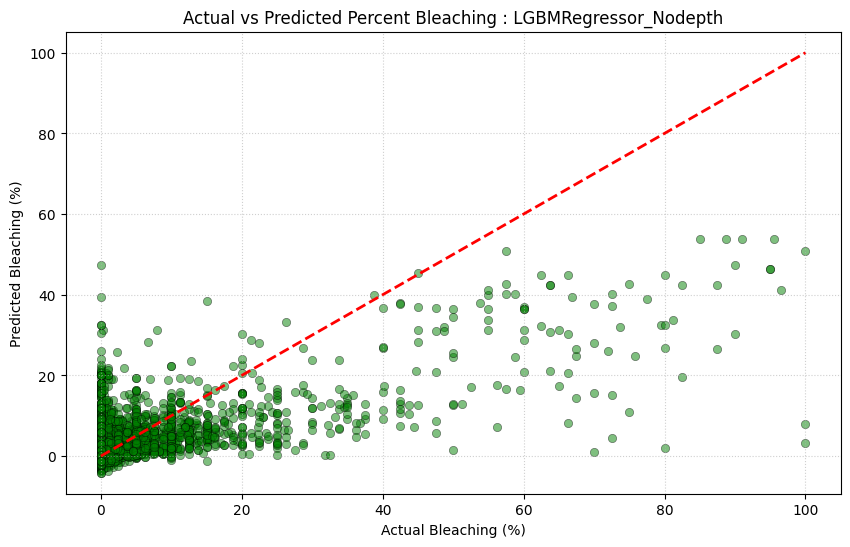


========== XGBRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.7411
Fold MAE  : 3.7011
Fold R2   : 0.1129

===== Fold 2 / 5 =====
Fold RMSE : 8.9127
Fold MAE  : 3.8700
Fold R2   : 0.2170

===== Fold 3 / 5 =====
Fold RMSE : 8.7902
Fold MAE  : 3.6605
Fold R2   : 0.2172

===== Fold 4 / 5 =====
Fold RMSE : 8.5534
Fold MAE  : 3.6553
Fold R2   : 0.1579

===== Fold 5 / 5 =====
Fold RMSE : 8.4360
Fold MAE  : 3.7444
Fold R2   : 0.2164


Mean RMSE : 8.6867
Mean MAE  : 3.7263
Mean R2   : 0.1843


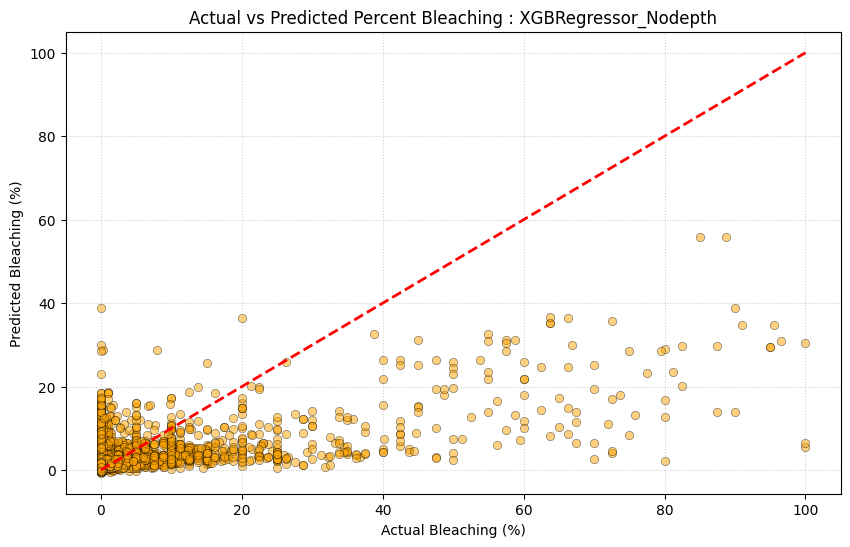


Feature Importance:
             feature  importance
1  Longitude_Degrees    0.277318
0   Latitude_Degrees    0.259551
2            ClimSST    0.249941
3               SSTA    0.213190


In [ ]:
all_results_model2th = []

for model, model_name, color in algo_model2th:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Cross_validarion_regression(
        feature_model2th.values,
        target_Baseline.values,
        model,
        n_splits=5
    )

    all_results_model2th.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_model2th.values,
        y_test=target_Baseline.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_model2th)
print("\nFeature Importance:")
print(feature_importance_df)

In [ ]:
search_rf_model2th = Hyperparameter_tunning(X_train_model2th, y_train_model2th)

best_model_model2th = search_rf_model2th.best_estimator_
print("CV R²  :", search_rf_model2th.best_score_)
print("Test R²:", best_model_model2th.score(X_test_model2th, y_test_model2th))
print("best parameters:", search_rf_model2th.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
CV R²  : 0.335310141592114
Test R²: 0.17450094751326384
best parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}


##

##

##

## model 2th : Increase factors is environmental

In [ ]:
factors_increase = ['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'SSTA', 'SSTA_DHW']
feature_model3th = df_Clean_already[factors_increase]
target_model3th = df_Clean_already['Percent_Bleaching']

algo_model3th = [
    [RandomForestRegressor(max_features = 'log2', 
                           max_depth = 20, 
                           criterion = 'squared_error', 
                           n_estimators = 300, 
                           min_samples_leaf = 1,
                           min_samples_split=2,
                           random_state = 42), 'RandomForestRegressor_Nodepth', 'green'],
    
    [lgb.LGBMRegressor(colsample_bytree=0.6, 
                       learning_rate=0.01, 
                       max_depth=-1, 
                       n_estimators=1000, 
                       num_leaves=50, 
                       subsample=1.0,
                       verbose=-1,
                       random_state=42), 'LGBMRegressor_Nodepth' , 'green'],
    
    [XGBRegressor(colsample_bytree=0.6, 
                  learning_rate=0.01, 
                  max_depth=5, 
                  min_child_weight=3, 
                  n_estimators=500, 
                  subsample=0.8, 
                  gamma=0.2,
                  verbosity=0,
                  random_state=42), 'XGBRegressor_Nodepth' , 'orange']

]

In [ ]:
X_train_model3th, X_test_model3th, y_train_model3th, y_test_model3th = X_train_test_split(feature_model3th.values, target_model3th.values)


========== RandomForestRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.1853
Fold MAE  : 3.1692
Fold R2   : 0.2221

===== Fold 2 / 5 =====
Fold RMSE : 7.5722
Fold MAE  : 3.0892
Fold R2   : 0.4348

===== Fold 3 / 5 =====
Fold RMSE : 7.3773
Fold MAE  : 2.9152
Fold R2   : 0.4486

===== Fold 4 / 5 =====
Fold RMSE : 7.6024
Fold MAE  : 3.0253
Fold R2   : 0.3348

===== Fold 5 / 5 =====
Fold RMSE : 6.6430
Fold MAE  : 2.9225
Fold R2   : 0.5141


Mean RMSE : 7.4760
Mean MAE  : 3.0243
Mean R2   : 0.3909


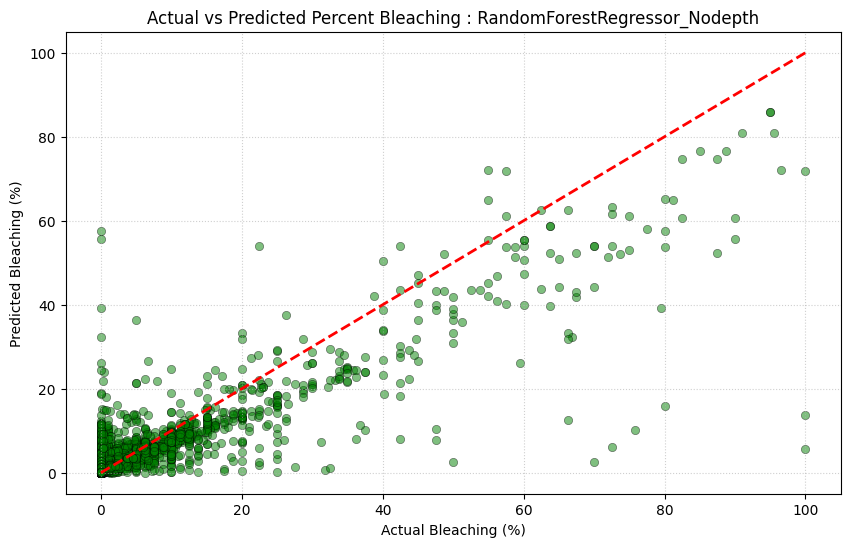


========== LGBMRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.3206
Fold MAE  : 3.6162
Fold R2   : 0.1962

===== Fold 2 / 5 =====
Fold RMSE : 8.1049
Fold MAE  : 3.4544
Fold R2   : 0.3525

===== Fold 3 / 5 =====
Fold RMSE : 7.8963
Fold MAE  : 3.3952
Fold R2   : 0.3683

===== Fold 4 / 5 =====
Fold RMSE : 8.0192
Fold MAE  : 3.3941
Fold R2   : 0.2598

===== Fold 5 / 5 =====
Fold RMSE : 7.0044
Fold MAE  : 3.3347
Fold R2   : 0.4598


Mean RMSE : 7.8691
Mean MAE  : 3.4389
Mean R2   : 0.3273


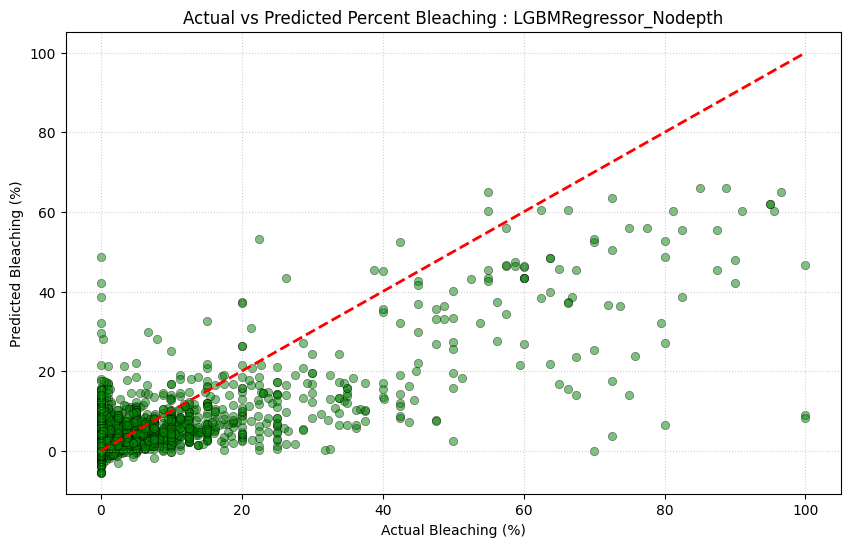


========== XGBRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.3941
Fold MAE  : 3.5499
Fold R2   : 0.1819

===== Fold 2 / 5 =====
Fold RMSE : 8.4769
Fold MAE  : 3.6512
Fold R2   : 0.2917

===== Fold 3 / 5 =====
Fold RMSE : 8.1545
Fold MAE  : 3.4633
Fold R2   : 0.3263

===== Fold 4 / 5 =====
Fold RMSE : 8.1224
Fold MAE  : 3.4483
Fold R2   : 0.2406

===== Fold 5 / 5 =====
Fold RMSE : 7.4843
Fold MAE  : 3.4270
Fold R2   : 0.3833


Mean RMSE : 8.1264
Mean MAE  : 3.5079
Mean R2   : 0.2848


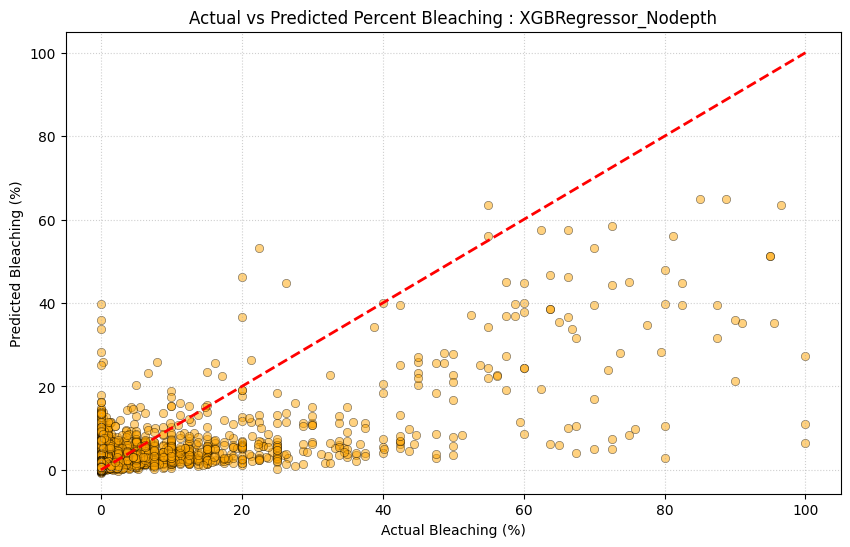


Feature Importance:
             feature  importance
4           SSTA_DHW    0.250838
0   Latitude_Degrees    0.208013
1  Longitude_Degrees    0.198890
2            ClimSST    0.195291
3               SSTA    0.146969


In [ ]:
all_results_model3th = []

for model, model_name, color in algo_model3th:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Cross_validarion_regression(
        feature_model3th.values,
        target_model3th.values,
        model,
        n_splits=5
    )

    all_results_model3th.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_model3th.values,
        y_test=target_model3th.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_model3th)
print("\nFeature Importance:")
print(feature_importance_df)

In [ ]:
search_rf_model3th = Hyperparameter_tunning(X_train_model3th, y_train_model3th)

best_model_model3th = search_rf_model3th.best_estimator_
print("CV R²  :", search_rf_model3th.best_score_)
print("Test R²:", best_model_model3th.score(X_test_model3th, y_test_model3th))
print("best parameters:", search_rf_model3th.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
CV R²  : 0.41270630775507033
Test R²: 0.2135163144145189
best parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}


##

##

##

In [ ]:
df_Interaction = df_Clean_already.copy()

In [ ]:
# Feature Engineering

df_Interaction['SSTA_X_ClimSST'] = df_Interaction['SSTA'] * df_Interaction['ClimSST']
df_Interaction['La_X_SSTA'] = df_Interaction['Latitude_Degrees'] * df_Interaction['SSTA']
df_Interaction['La_X_ClimSST'] = df_Interaction['Latitude_Degrees'] * df_Interaction['ClimSST']
df_Interaction['La_X_SSTA_DHW'] = df_Interaction['Latitude_Degrees'] * df_Interaction['SSTA_DHW']


In [ ]:
df_Interaction

,Latitude_Degrees,Longitude_Degrees,Depth_m,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,...,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Year,SSTA_X_ClimSST,La_X_SSTA,La_X_ClimSST,La_X_SSTA_DHW
0,-20.899833,149.407722,4.0,6.25,297.78,301.670,298.17,291.910000,303.850,2.740,...,1.0,3.52,1.360000,8.43,0.520000,2016,393.069600,-27.587780,-6223.552369,-82.763340
1,-20.893056,149.421000,5.0,8.75,297.78,301.670,298.17,291.910000,303.850,2.740,...,1.0,3.52,1.360000,8.43,0.520000,2016,393.069600,-27.578833,-6221.534085,-82.736500
2,-20.745806,149.472056,6.0,11.25,298.17,301.380,298.34,292.670000,303.760,2.570,...,1.0,1.51,1.230000,7.32,0.490000,2016,259.407900,-18.048851,-6185.776844,-55.598759
3,-20.737694,149.464944,5.0,25.00,298.21,301.560,298.37,292.010000,304.040,2.520,...,1.0,2.36,0.970000,6.86,0.360000,2016,319.084700,-22.189333,-6184.187859,-75.692585
4,-20.259361,148.814583,2.0,1.00,296.48,296.380,298.47,291.830000,304.540,2.700,...,1.0,0.00,1.470000,9.84,0.560000,2017,521.804800,-35.656476,-6006.495382,-77.795947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9641,20.738889,107.058333,3.2,0.00,262.15,302.955,298.07,288.423333,306.535,4.495,...,1.0,0.00,1.381667,11.57,0.446667,2003,8.738333,0.691296,5436.699723,49.323991
9646,20.845833,107.177778,3.0,0.00,299.80,302.300,298.09,289.690000,307.260,4.360,...,1.0,0.00,1.740000,12.00,0.640000,2003,152.898000,10.631375,6249.580832,0.000000
9649,12.601722,53.817306,6.0,0.00,301.40,302.670,299.38,294.550000,309.550,1.980,...,0.0,0.00,1.710000,19.41,0.370000,2008,15.070000,0.630086,3798.159077,0.000000
9663,15.701611,42.391806,9.0,0.00,304.39,303.890,301.97,296.610000,307.200,2.400,...,1.0,0.00,1.330000,8.30,0.540000,2008,33.482900,1.727177,4779.413406,35.328625


##

##

## model 3th : M2 + X1×X2 เพิ่ม interaction ทีละตัว

In [ ]:
factors_interaction_F1 = ['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'SSTA', 'SSTA_DHW','La_X_SSTA']
feature_model3th = df_Interaction[factors_interaction_F1]
target_model3th = df_Interaction['Percent_Bleaching']

In [ ]:
X_train_model3th, X_test_model3th, y_train_model3th, y_test_model3th = X_train_test_split(feature_model3th.values, target_model3th.values)

In [ ]:
algo_model3th = [
    [RandomForestRegressor(max_features = 'log2', 
                           max_depth = 20, 
                           criterion = 'squared_error', 
                           n_estimators = 300, 
                           min_samples_leaf = 1,
                           min_samples_split=2,
                           random_state = 42), 'RandomForestRegressor_Nodepth', 'green'],
    
    [lgb.LGBMRegressor(colsample_bytree=0.6, 
                       learning_rate=0.01, 
                       max_depth=-1, 
                       n_estimators=1000, 
                       num_leaves=50, 
                       subsample=1.0,
                       verbose=-1,
                       random_state=42), 'LGBMRegressor_Nodepth' , 'green'],
    
    [XGBRegressor(colsample_bytree=0.6, 
                  learning_rate=0.01, 
                  max_depth=5, 
                  min_child_weight=3, 
                  n_estimators=500, 
                  subsample=0.8, 
                  gamma=0.2,
                  verbosity=0,
                  random_state=42), 'XGBRegressor_Nodepth' , 'orange']

]


========== RandomForestRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.1787
Fold MAE  : 3.1792
Fold R2   : 0.2233

===== Fold 2 / 5 =====
Fold RMSE : 7.6505
Fold MAE  : 3.1326
Fold R2   : 0.4231

===== Fold 3 / 5 =====
Fold RMSE : 7.3516
Fold MAE  : 2.9202
Fold R2   : 0.4525

===== Fold 4 / 5 =====
Fold RMSE : 7.6585
Fold MAE  : 3.0698
Fold R2   : 0.3249

===== Fold 5 / 5 =====
Fold RMSE : 6.6413
Fold MAE  : 2.9524
Fold R2   : 0.5144


Mean RMSE : 7.4961
Mean MAE  : 3.0508
Mean R2   : 0.3876


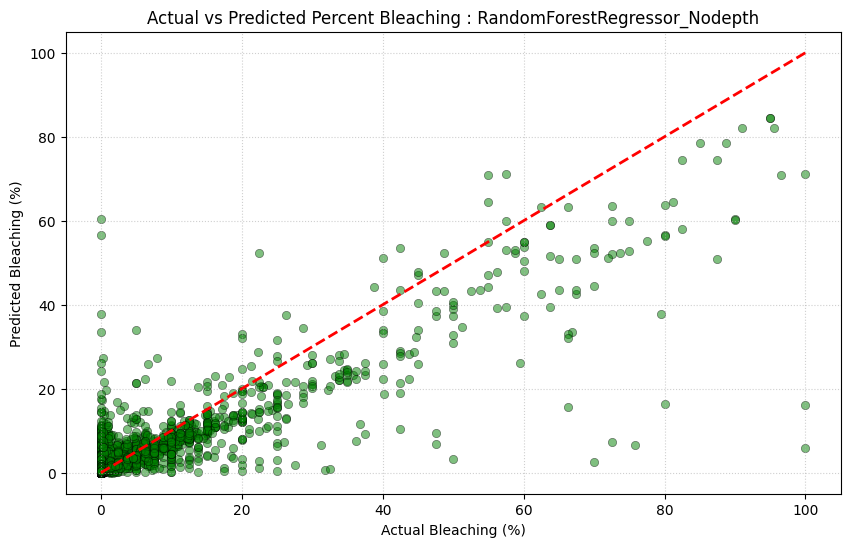


========== LGBMRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.2703
Fold MAE  : 3.5372
Fold R2   : 0.2059

===== Fold 2 / 5 =====
Fold RMSE : 7.9956
Fold MAE  : 3.4061
Fold R2   : 0.3698

===== Fold 3 / 5 =====
Fold RMSE : 7.7392
Fold MAE  : 3.3332
Fold R2   : 0.3932

===== Fold 4 / 5 =====
Fold RMSE : 7.9028
Fold MAE  : 3.3550
Fold R2   : 0.2811

===== Fold 5 / 5 =====
Fold RMSE : 6.9096
Fold MAE  : 3.2817
Fold R2   : 0.4744


Mean RMSE : 7.7635
Mean MAE  : 3.3826
Mean R2   : 0.3449


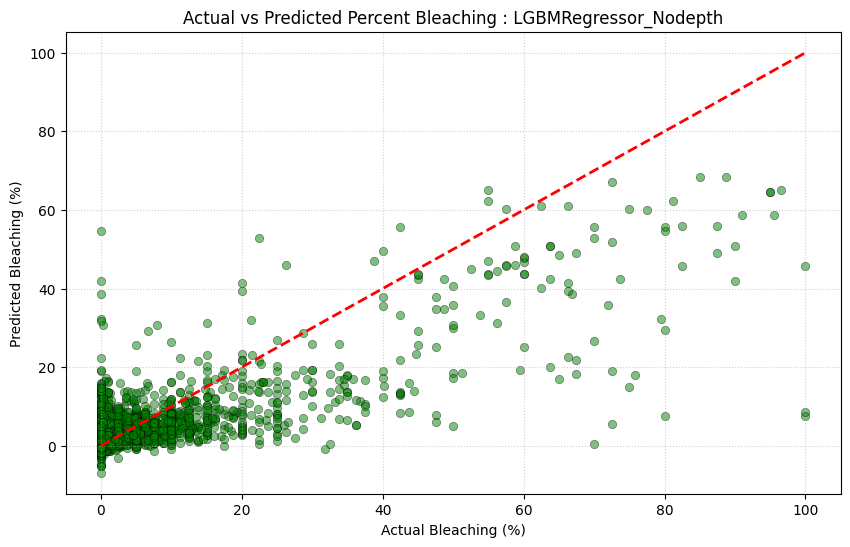


========== XGBRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.3448
Fold MAE  : 3.5320
Fold R2   : 0.1915

===== Fold 2 / 5 =====
Fold RMSE : 8.4873
Fold MAE  : 3.6701
Fold R2   : 0.2899

===== Fold 3 / 5 =====
Fold RMSE : 8.2280
Fold MAE  : 3.4778
Fold R2   : 0.3141

===== Fold 4 / 5 =====
Fold RMSE : 8.1629
Fold MAE  : 3.4810
Fold R2   : 0.2330

===== Fold 5 / 5 =====
Fold RMSE : 7.5162
Fold MAE  : 3.4568
Fold R2   : 0.3780


Mean RMSE : 8.1478
Mean MAE  : 3.5235
Mean R2   : 0.2813


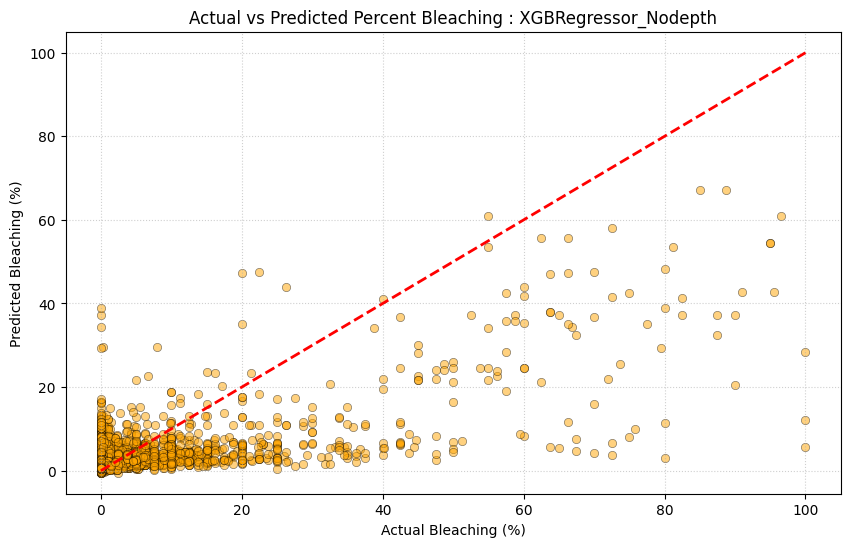


Feature Importance:
             feature  importance
4           SSTA_DHW    0.217048
0   Latitude_Degrees    0.190364
1  Longitude_Degrees    0.185612
2            ClimSST    0.156167
5          La_X_SSTA    0.125603
3               SSTA    0.125206


In [ ]:
all_results_model3th = []

for model, model_name, color in algo_model3th:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Cross_validarion_regression(
        feature_model3th.values,
        target_model3th.values,
        model,
        n_splits=5
    )

    all_results_model3th.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_model3th.values,
        y_test=target_model3th.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_model3th)
print("\nFeature Importance:")
print(feature_importance_df)

In [ ]:
search_rf_model3th = Hyperparameter_tunning(X_train_model3th, y_train_model3th)

best_model_model3th = search_rf_model3th.best_estimator_
print("CV R²  :", search_rf_model3th.best_score_)
print("Test R²:", best_model_model3th.score(X_test_model3th, y_test_model3th))
print("best parameters:", search_rf_model3th.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
CV R²  : 0.4085877045248483
Test R²: 0.22247234463982168
best parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}


##

##

## model 4th : M2 + X1×X3 เพิ่ม interaction ทีละตัว

In [ ]:
factors_interaction_F2 = ['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'SSTA', 'SSTA_DHW','La_X_ClimSST']
feature_model4th = df_Interaction[factors_interaction_F2]
target_model4th = df_Interaction['Percent_Bleaching']

In [ ]:
X_train_model4th, X_test_model4th, y_train_model4th, y_test_model4th = train_test_split(feature_model4th.values, target_model4th.values, test_size=0.2, random_state=42)

In [ ]:
algo_model4th = [
    [RandomForestRegressor(max_features = 'sqrt', 
                           max_depth = 20, 
                           criterion = 'squared_error', 
                           n_estimators = 800, 
                           min_samples_leaf = 1,
                           min_samples_split=2,
                           random_state = 42), 'RandomForestRegressor_Nodepth', 'green'],
    
    [lgb.LGBMRegressor(colsample_bytree=0.6, 
                       learning_rate=0.01, 
                       max_depth=-1, 
                       n_estimators=1000, 
                       num_leaves=50, 
                       subsample=1.0,
                       verbose=-1,
                       random_state=42), 'LGBMRegressor_Nodepth' , 'green'],
    
    [XGBRegressor(colsample_bytree=0.6, 
                  learning_rate=0.01, 
                  max_depth=5, 
                  min_child_weight=3, 
                  n_estimators=500, 
                  subsample=0.8, 
                  gamma=0.2,
                  verbosity=0,
                  random_state=42), 'XGBRegressor_Nodepth' , 'orange']

]


========== RandomForestRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.1339
Fold MAE  : 3.1363
Fold R2   : 0.2318

===== Fold 2 / 5 =====
Fold RMSE : 7.5831
Fold MAE  : 3.0686
Fold R2   : 0.4332

===== Fold 3 / 5 =====
Fold RMSE : 7.3383
Fold MAE  : 2.8676
Fold R2   : 0.4544

===== Fold 4 / 5 =====
Fold RMSE : 7.5604
Fold MAE  : 2.9803
Fold R2   : 0.3421

===== Fold 5 / 5 =====
Fold RMSE : 6.6222
Fold MAE  : 2.8944
Fold R2   : 0.5172


Mean RMSE : 7.4476
Mean MAE  : 2.9894
Mean R2   : 0.3957


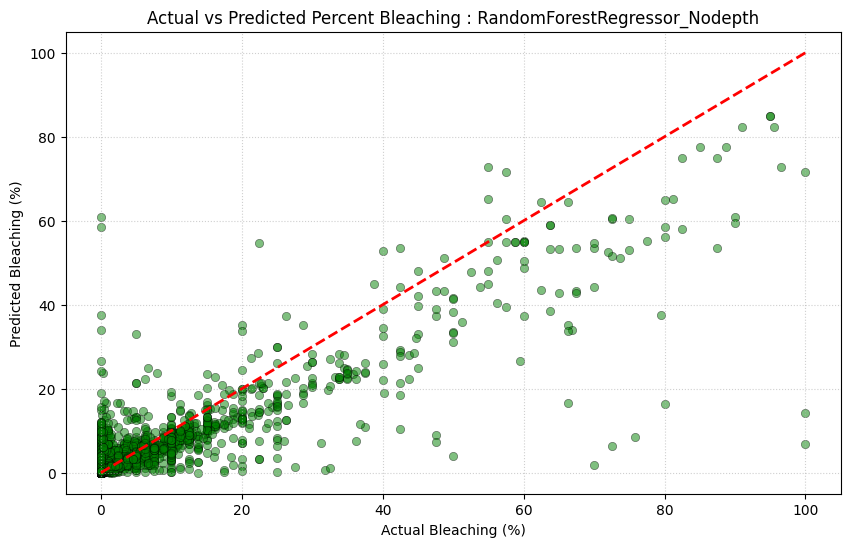


========== LGBMRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.2053
Fold MAE  : 3.5313
Fold R2   : 0.2183

===== Fold 2 / 5 =====
Fold RMSE : 8.1136
Fold MAE  : 3.4731
Fold R2   : 0.3511

===== Fold 3 / 5 =====
Fold RMSE : 7.7181
Fold MAE  : 3.2859
Fold R2   : 0.3965

===== Fold 4 / 5 =====
Fold RMSE : 7.8847
Fold MAE  : 3.3345
Fold R2   : 0.2844

===== Fold 5 / 5 =====
Fold RMSE : 6.9783
Fold MAE  : 3.2378
Fold R2   : 0.4638


Mean RMSE : 7.7800
Mean MAE  : 3.3725
Mean R2   : 0.3428


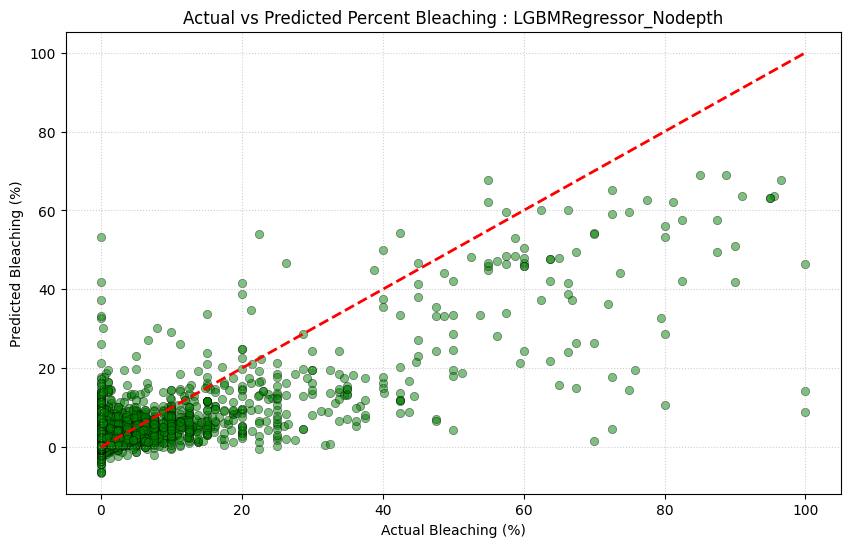


========== XGBRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.3621
Fold MAE  : 3.5419
Fold R2   : 0.1881

===== Fold 2 / 5 =====
Fold RMSE : 8.5112
Fold MAE  : 3.6741
Fold R2   : 0.2859

===== Fold 3 / 5 =====
Fold RMSE : 8.1237
Fold MAE  : 3.4458
Fold R2   : 0.3314

===== Fold 4 / 5 =====
Fold RMSE : 8.0485
Fold MAE  : 3.4324
Fold R2   : 0.2544

===== Fold 5 / 5 =====
Fold RMSE : 7.5170
Fold MAE  : 3.4316
Fold R2   : 0.3779


Mean RMSE : 8.1125
Mean MAE  : 3.5051
Mean R2   : 0.2875


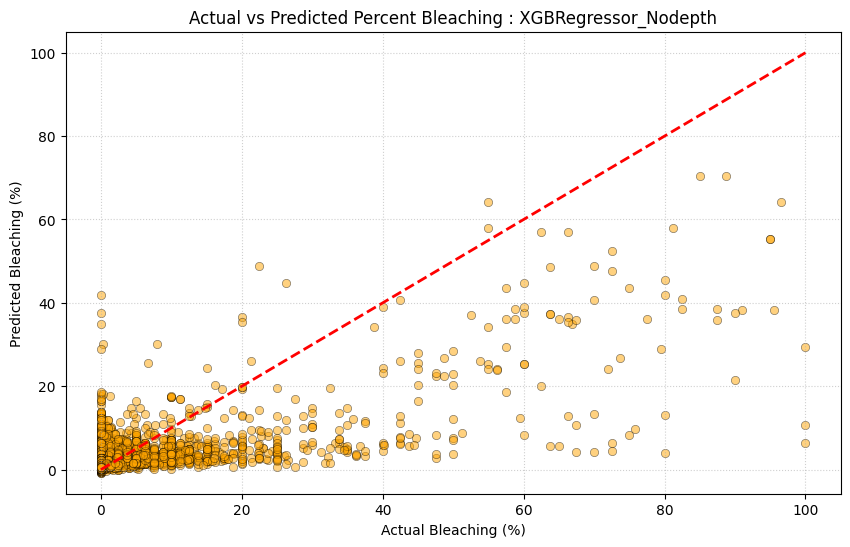


Feature Importance:
             feature  importance
4           SSTA_DHW    0.199584
0   Latitude_Degrees    0.179293
5       La_X_ClimSST    0.172160
1  Longitude_Degrees    0.170527
2            ClimSST    0.147941
3               SSTA    0.130496


In [ ]:
all_results_model4th = []

for model, model_name, color in algo_model4th:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Cross_validarion_regression(
        feature_model4th.values,
        target_model4th.values,
        model,
        n_splits=5
    )

    all_results_model4th.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_model4th.values,
        y_test=target_model4th.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_model4th)
print("\nFeature Importance:")
print(feature_importance_df)

In [ ]:
search_rf_model4th = Hyperparameter_tunning(X_train_model4th, y_train_model4th)

best_model_model4th = search_rf_model4th.best_estimator_
print("CV R²  :", search_rf_model4th.best_score_)
print("Test R²:", best_model_model4th.score(X_test_model4th, y_test_model4th))
print("best parameters:", search_rf_model4th.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
CV R²  : 0.419073327832689
Test R²: 0.22756830817261564
best parameters: {'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}


##

##

##

## model 5th : M2 + X1×X6 เพิ่ม interaction ทีละตัว

In [ ]:
factors_interaction_F3 = ['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'SSTA', 'SSTA_DHW','La_X_SSTA_DHW']
feature_model5th = df_Interaction[factors_interaction_F3]
target_model5th = df_Interaction['Percent_Bleaching']

In [ ]:
X_train_model5th, X_test_model5th, y_train_model5th, y_test_model5th = train_test_split(feature_model5th.values, target_model5th.values, test_size=0.2, random_state=42)

In [ ]:
algo_model5th = [
    [RandomForestRegressor(max_features = 'sqrt', 
                           max_depth = 20, 
                           criterion = 'squared_error', 
                           n_estimators = 800, 
                           min_samples_leaf = 1,
                           min_samples_split=2,
                           random_state = 42), 'RandomForestRegressor_Nodepth', 'green'],
    
    [lgb.LGBMRegressor(colsample_bytree=0.6, 
                       learning_rate=0.01, 
                       max_depth=-1, 
                       n_estimators=1000, 
                       num_leaves=50, 
                       subsample=1.0,
                       verbose=-1,
                       random_state=42), 'LGBMRegressor_Nodepth' , 'green'],
    
    [XGBRegressor(colsample_bytree=0.6, 
                  learning_rate=0.01, 
                  max_depth=5, 
                  min_child_weight=3, 
                  n_estimators=500, 
                  subsample=0.8, 
                  gamma=0.2,
                  verbosity=0,
                  random_state=42), 'XGBRegressor_Nodepth' , 'orange']

]


========== RandomForestRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.1467
Fold MAE  : 3.1517
Fold R2   : 0.2294

===== Fold 2 / 5 =====
Fold RMSE : 7.7027
Fold MAE  : 3.1390
Fold R2   : 0.4152

===== Fold 3 / 5 =====
Fold RMSE : 7.2927
Fold MAE  : 2.8766
Fold R2   : 0.4612

===== Fold 4 / 5 =====
Fold RMSE : 7.5785
Fold MAE  : 3.0319
Fold R2   : 0.3389

===== Fold 5 / 5 =====
Fold RMSE : 6.6556
Fold MAE  : 2.9403
Fold R2   : 0.5123


Mean RMSE : 7.4752
Mean MAE  : 3.0279
Mean R2   : 0.3914


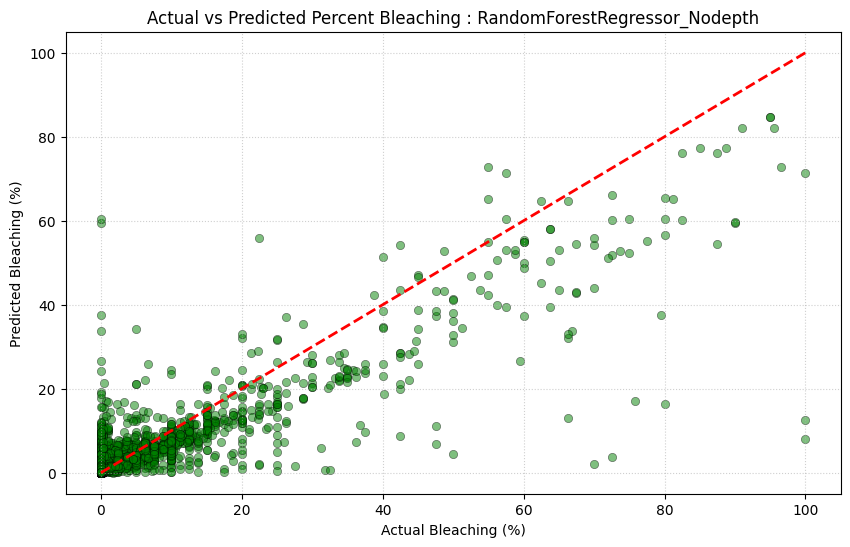


========== LGBMRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.3130
Fold MAE  : 3.4839
Fold R2   : 0.1976

===== Fold 2 / 5 =====
Fold RMSE : 8.1970
Fold MAE  : 3.4501
Fold R2   : 0.3377

===== Fold 3 / 5 =====
Fold RMSE : 7.7259
Fold MAE  : 3.3222
Fold R2   : 0.3953

===== Fold 4 / 5 =====
Fold RMSE : 7.8930
Fold MAE  : 3.3364
Fold R2   : 0.2829

===== Fold 5 / 5 =====
Fold RMSE : 6.8061
Fold MAE  : 3.1966
Fold R2   : 0.4900


Mean RMSE : 7.7870
Mean MAE  : 3.3578
Mean R2   : 0.3407


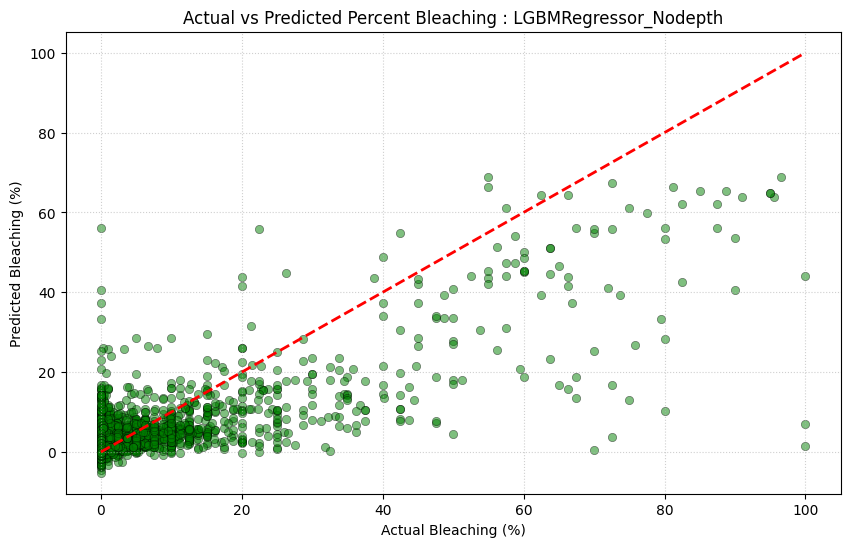


========== XGBRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.2906
Fold MAE  : 3.5126
Fold R2   : 0.2020

===== Fold 2 / 5 =====
Fold RMSE : 8.4843
Fold MAE  : 3.6529
Fold R2   : 0.2904

===== Fold 3 / 5 =====
Fold RMSE : 8.0107
Fold MAE  : 3.4019
Fold R2   : 0.3499

===== Fold 4 / 5 =====
Fold RMSE : 7.9797
Fold MAE  : 3.4618
Fold R2   : 0.2671

===== Fold 5 / 5 =====
Fold RMSE : 7.4194
Fold MAE  : 3.3863
Fold R2   : 0.3939


Mean RMSE : 8.0369
Mean MAE  : 3.4831
Mean R2   : 0.3007


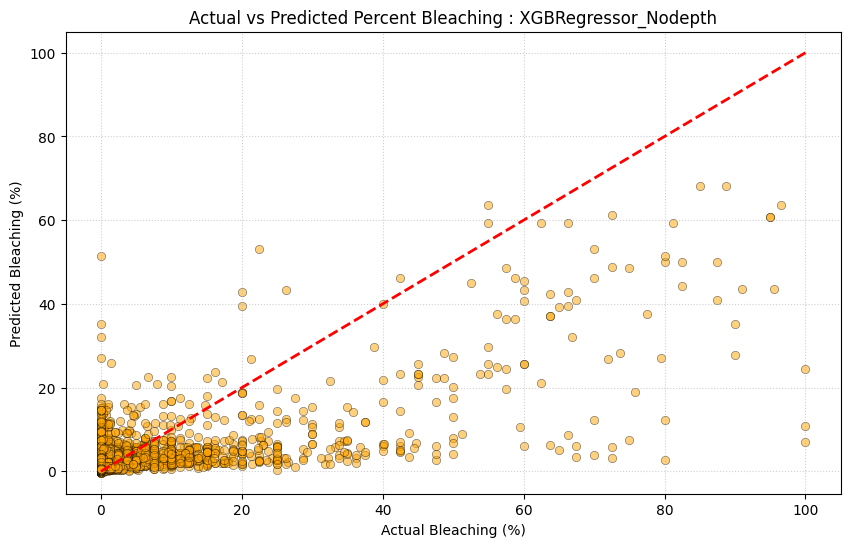


Feature Importance:
             feature  importance
1  Longitude_Degrees    0.189109
0   Latitude_Degrees    0.181900
5      La_X_SSTA_DHW    0.174805
4           SSTA_DHW    0.166847
3               SSTA    0.145887
2            ClimSST    0.141452


In [ ]:
all_results_model5th = []

for model, model_name, color in algo_model5th:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Cross_validarion_regression(
        feature_model5th.values,
        target_model5th.values,
        model,
        n_splits=5
    )

    all_results_model5th.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_model5th.values,
        y_test=target_model5th.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_model5th)
print("\nFeature Importance:")
print(feature_importance_df)

In [ ]:
search_rf_model5th = Hyperparameter_tunning(X_train_model5th, y_train_model5th)

best_model_model5th = search_rf_model5th.best_estimator_
print("CV R²  :", search_rf_model5th.best_score_)
print("Test R²:", best_model_model5th.score(X_test_model5th, y_test_model5th))
print("best parameters:", search_rf_model5th.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
CV R²  : 0.41440188118784704
Test R²: 0.2291415152602001
best parameters: {'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}


##

##

##

## model 6th : ✅M2 + X1×X2 + X1×X3 + X1×X6Full model ของคุณ

In [ ]:
factors_interaction_FullFE = ['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'SSTA', 'SSTA_DHW','La_X_SSTA_DHW', 'La_X_SSTA', 'La_X_ClimSST']
feature_model6th = df_Interaction[factors_interaction_FullFE]
target_model6th = df_Interaction['Percent_Bleaching']

In [ ]:
X_train_model6th, X_test_model6th, y_train_model6th, y_test_model6th = train_test_split(feature_model6th.values, target_model6th.values, test_size=0.2, random_state=42)

In [ ]:
algo_model6th = [
    [RandomForestRegressor(max_features = 'sqrt', 
                           max_depth = 20, 
                           criterion = 'squared_error', 
                           n_estimators = 800, 
                           min_samples_leaf = 1,
                           min_samples_split=2,
                           random_state = 42), 'RandomForestRegressor_Nodepth', 'green'],
    
    [lgb.LGBMRegressor(colsample_bytree=0.6, 
                       learning_rate=0.01, 
                       max_depth=-1, 
                       n_estimators=1000, 
                       num_leaves=50, 
                       subsample=1.0,
                       verbose=-1,
                       random_state=42), 'LGBMRegressor_Nodepth' , 'green'],
    
    [XGBRegressor(colsample_bytree=0.6, 
                  learning_rate=0.01, 
                  max_depth=5, 
                  min_child_weight=3, 
                  n_estimators=500, 
                  subsample=0.8, 
                  gamma=0.2,
                  verbosity=0,
                  random_state=42), 'XGBRegressor_Nodepth' , 'orange']

]


========== RandomForestRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.0906
Fold MAE  : 3.1453
Fold R2   : 0.2400

===== Fold 2 / 5 =====
Fold RMSE : 7.7045
Fold MAE  : 3.1411
Fold R2   : 0.4149

===== Fold 3 / 5 =====
Fold RMSE : 7.3309
Fold MAE  : 2.8603
Fold R2   : 0.4555

===== Fold 4 / 5 =====
Fold RMSE : 7.5836
Fold MAE  : 3.0417
Fold R2   : 0.3380

===== Fold 5 / 5 =====
Fold RMSE : 6.6046
Fold MAE  : 2.9240
Fold R2   : 0.5197


Mean RMSE : 7.4628
Mean MAE  : 3.0225
Mean R2   : 0.3936


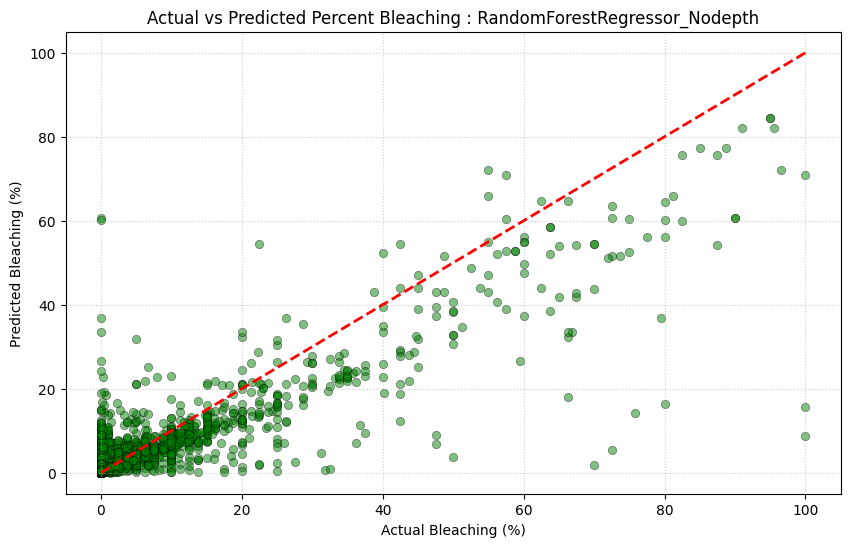


========== LGBMRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.2257
Fold MAE  : 3.4444
Fold R2   : 0.2144

===== Fold 2 / 5 =====
Fold RMSE : 8.2216
Fold MAE  : 3.4549
Fold R2   : 0.3337

===== Fold 3 / 5 =====
Fold RMSE : 7.7222
Fold MAE  : 3.2805
Fold R2   : 0.3959

===== Fold 4 / 5 =====
Fold RMSE : 7.9383
Fold MAE  : 3.3811
Fold R2   : 0.2747

===== Fold 5 / 5 =====
Fold RMSE : 6.7467
Fold MAE  : 3.1646
Fold R2   : 0.4988


Mean RMSE : 7.7709
Mean MAE  : 3.3451
Mean R2   : 0.3435


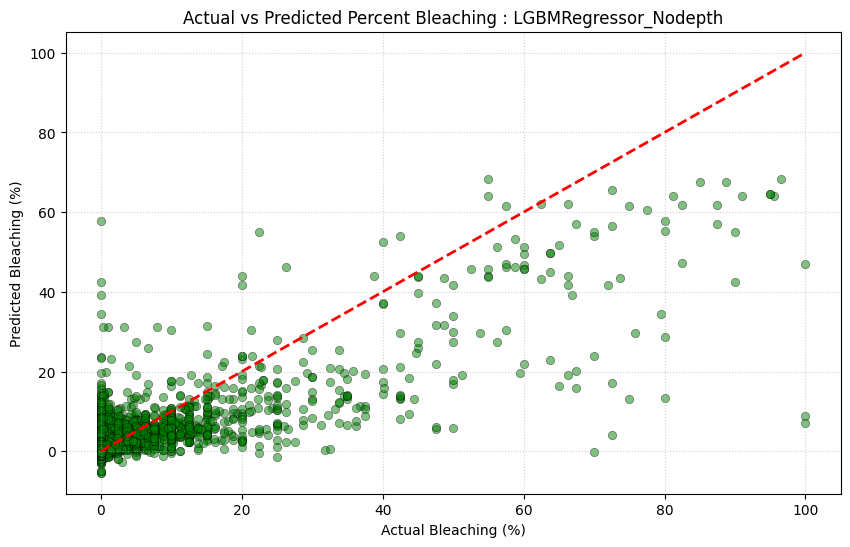


========== XGBRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.2804
Fold MAE  : 3.4998
Fold R2   : 0.2039

===== Fold 2 / 5 =====
Fold RMSE : 8.4131
Fold MAE  : 3.6489
Fold R2   : 0.3023

===== Fold 3 / 5 =====
Fold RMSE : 7.9729
Fold MAE  : 3.3618
Fold R2   : 0.3560

===== Fold 4 / 5 =====
Fold RMSE : 7.9164
Fold MAE  : 3.4350
Fold R2   : 0.2787

===== Fold 5 / 5 =====
Fold RMSE : 7.3269
Fold MAE  : 3.3659
Fold R2   : 0.4089


Mean RMSE : 7.9820
Mean MAE  : 3.4623
Mean R2   : 0.3100


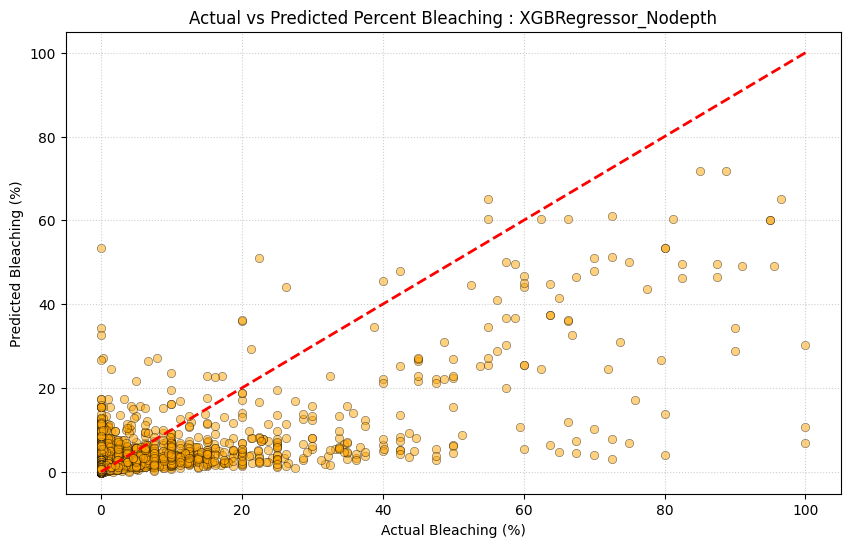


Feature Importance:
             feature  importance
1  Longitude_Degrees    0.149450
7       La_X_ClimSST    0.137292
5      La_X_SSTA_DHW    0.135691
0   Latitude_Degrees    0.120589
4           SSTA_DHW    0.120501
2            ClimSST    0.117956
6          La_X_SSTA    0.110433
3               SSTA    0.108087


In [ ]:
all_results_model6th = []

for model, model_name, color in algo_model6th:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Cross_validarion_regression(
        feature_model6th.values,
        target_model6th.values,
        model,
        n_splits=5
    )

    all_results_model6th.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_model6th.values,
        y_test=target_model6th.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_model6th)
print("\nFeature Importance:")
print(feature_importance_df)

In [ ]:
search_rf_model6th = Hyperparameter_tunning(X_train_model6th, y_train_model6th)

best_model_model6th = search_rf_model6th.best_estimator_
print("CV R²  :", search_rf_model6th.best_score_)
print("Test R²:", best_model_model6th.score(X_test_model6th, y_test_model6th))
print("best parameters:", search_rf_model6th.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
CV R²  : 0.4130884014570033
Test R²: 0.24135237806207888
best parameters: {'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}


##

##

## model 8th : M2 + X1×X2 + X1×X3  model ของคุณ

In [ ]:
factors_interaction_F12 = ['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'SSTA', 'SSTA_DHW', 'La_X_SSTA', 'La_X_ClimSST']
feature_model8th = df_Interaction[factors_interaction_F12]
target_model8th = df_Interaction['Percent_Bleaching']

In [ ]:
X_train_model8th, X_test_model8th, y_train_model8th, y_test_model8th = train_test_split(feature_model8th.values, target_model8th.values, test_size=0.2, random_state=42)

In [ ]:
algo_model8th = [
    [RandomForestRegressor(max_features = 'sqrt', 
                           max_depth = 20, 
                           criterion = 'squared_error', 
                           n_estimators = 800, 
                           min_samples_leaf = 1,
                           min_samples_split=2,
                           random_state = 42), 'RandomForestRegressor_Nodepth', 'green'],
    
    [lgb.LGBMRegressor(colsample_bytree=0.6, 
                       learning_rate=0.01, 
                       max_depth=-1, 
                       n_estimators=1000, 
                       num_leaves=50, 
                       subsample=1.0,
                       verbose=-1,
                       random_state=42), 'LGBMRegressor_Nodepth' , 'green'],
    
    [XGBRegressor(colsample_bytree=0.6, 
                  learning_rate=0.01, 
                  max_depth=5, 
                  min_child_weight=3, 
                  n_estimators=500, 
                  subsample=0.8, 
                  gamma=0.2,
                  verbosity=0,
                  random_state=42), 'XGBRegressor_Nodepth' , 'orange']

]


========== RandomForestRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.1368
Fold MAE  : 3.1465
Fold R2   : 0.2313

===== Fold 2 / 5 =====
Fold RMSE : 7.6376
Fold MAE  : 3.0968
Fold R2   : 0.4250

===== Fold 3 / 5 =====
Fold RMSE : 7.3541
Fold MAE  : 2.8983
Fold R2   : 0.4521

===== Fold 4 / 5 =====
Fold RMSE : 7.6131
Fold MAE  : 3.0272
Fold R2   : 0.3329

===== Fold 5 / 5 =====
Fold RMSE : 6.6317
Fold MAE  : 2.9382
Fold R2   : 0.5158


Mean RMSE : 7.4746
Mean MAE  : 3.0214
Mean R2   : 0.3914


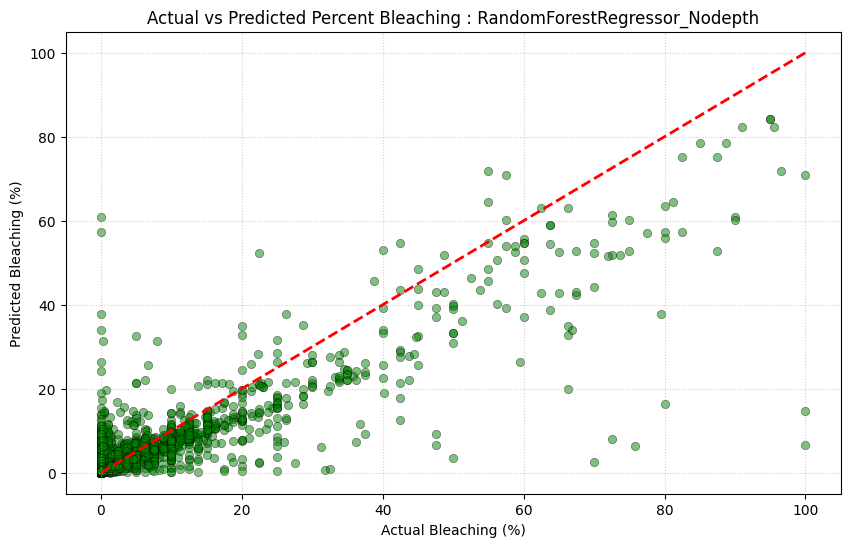


========== LGBMRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.1671
Fold MAE  : 3.5226
Fold R2   : 0.2256

===== Fold 2 / 5 =====
Fold RMSE : 7.9672
Fold MAE  : 3.4255
Fold R2   : 0.3743

===== Fold 3 / 5 =====
Fold RMSE : 7.7755
Fold MAE  : 3.3132
Fold R2   : 0.3875

===== Fold 4 / 5 =====
Fold RMSE : 7.8965
Fold MAE  : 3.3334
Fold R2   : 0.2823

===== Fold 5 / 5 =====
Fold RMSE : 6.9440
Fold MAE  : 3.2880
Fold R2   : 0.4691


Mean RMSE : 7.7501
Mean MAE  : 3.3766
Mean R2   : 0.3477


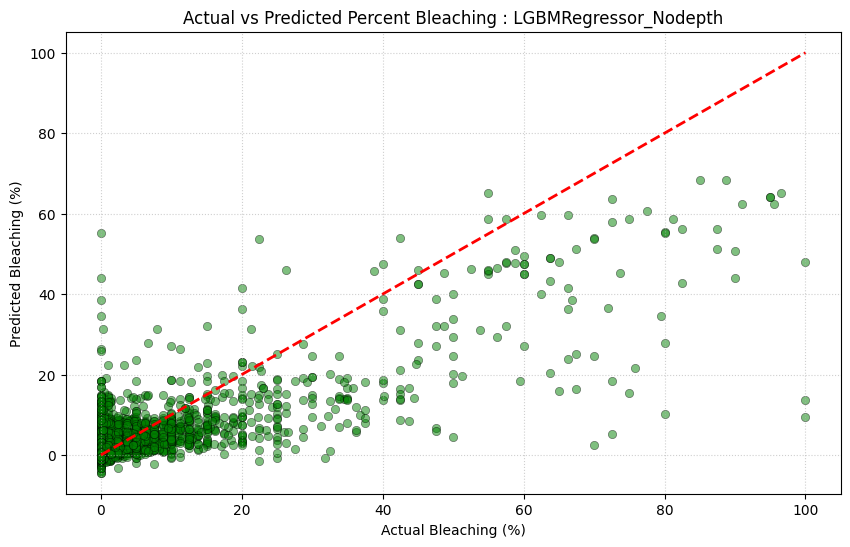


========== XGBRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.3685
Fold MAE  : 3.5255
Fold R2   : 0.1869

===== Fold 2 / 5 =====
Fold RMSE : 8.4329
Fold MAE  : 3.6468
Fold R2   : 0.2990

===== Fold 3 / 5 =====
Fold RMSE : 8.0824
Fold MAE  : 3.4105
Fold R2   : 0.3382

===== Fold 4 / 5 =====
Fold RMSE : 8.0379
Fold MAE  : 3.4540
Fold R2   : 0.2564

===== Fold 5 / 5 =====
Fold RMSE : 7.3764
Fold MAE  : 3.3907
Fold R2   : 0.4009


Mean RMSE : 8.0596
Mean MAE  : 3.4855
Mean R2   : 0.2963


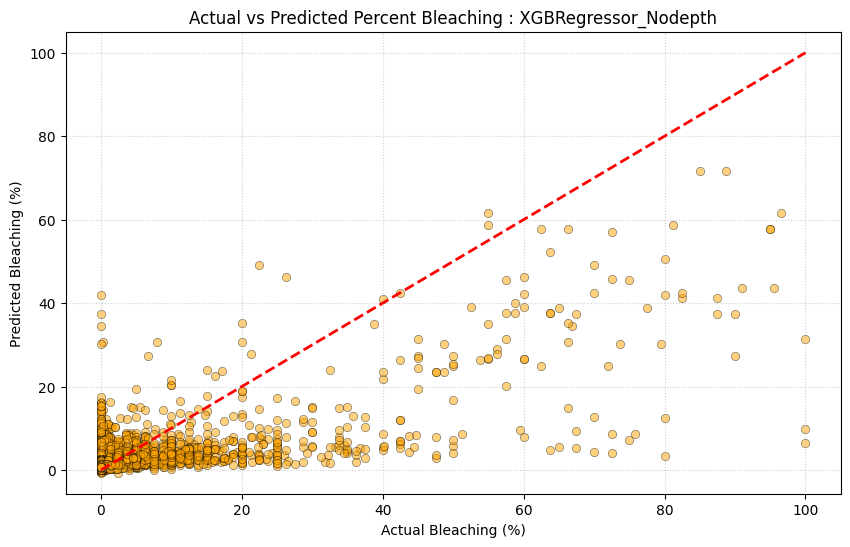


Feature Importance:
             feature  importance
4           SSTA_DHW    0.190162
1  Longitude_Degrees    0.161347
6       La_X_ClimSST    0.159325
2            ClimSST    0.142485
0   Latitude_Degrees    0.125879
5          La_X_SSTA    0.111544
3               SSTA    0.109258


In [ ]:
all_results_model8th = []

for model, model_name, color in algo_model8th:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Cross_validarion_regression(
        feature_model8th.values,
        target_model8th.values,
        model,
        n_splits=5
    )

    all_results_model8th.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_model8th.values,
        y_test=target_model8th.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_model8th)
print("\nFeature Importance:")
print(feature_importance_df)

##

##

##

## model 9th : M2 + X1×X2 + X1×X6  model ของคุณ

In [ ]:
factors_interaction_F13 = ['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'SSTA', 'SSTA_DHW', 'La_X_SSTA', 'La_X_SSTA_DHW']
feature_model9th = df_Interaction[factors_interaction_F13]
target_model9th = df_Interaction['Percent_Bleaching']

In [ ]:
X_train_model9th, X_test_model9th, y_train_model9th, y_test_model9th = train_test_split(feature_model9th.values, target_model9th.values, test_size=0.2, random_state=42)

In [ ]:
algo_model9th = [
    [RandomForestRegressor(max_features = 'sqrt', 
                           max_depth = 20, 
                           criterion = 'squared_error', 
                           n_estimators = 800, 
                           min_samples_leaf = 1,
                           min_samples_split=2,
                           random_state = 42), 'RandomForestRegressor_Nodepth', 'green'],
    
    [lgb.LGBMRegressor(colsample_bytree=0.6, 
                       learning_rate=0.01, 
                       max_depth=-1, 
                       n_estimators=1000, 
                       num_leaves=50, 
                       subsample=1.0,
                       verbose=-1,
                       random_state=42), 'LGBMRegressor_Nodepth' , 'green'],
    
    [XGBRegressor(colsample_bytree=0.6, 
                  learning_rate=0.01, 
                  max_depth=5, 
                  min_child_weight=3, 
                  n_estimators=500, 
                  subsample=0.8, 
                  gamma=0.2,
                  verbosity=0,
                  random_state=42), 'XGBRegressor_Nodepth' , 'orange']

]


========== RandomForestRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.1217
Fold MAE  : 3.1667
Fold R2   : 0.2341

===== Fold 2 / 5 =====
Fold RMSE : 7.6732
Fold MAE  : 3.1225
Fold R2   : 0.4196

===== Fold 3 / 5 =====
Fold RMSE : 7.3318
Fold MAE  : 2.9005
Fold R2   : 0.4554

===== Fold 4 / 5 =====
Fold RMSE : 7.6346
Fold MAE  : 3.0768
Fold R2   : 0.3291

===== Fold 5 / 5 =====
Fold RMSE : 6.6340
Fold MAE  : 2.9500
Fold R2   : 0.5154


Mean RMSE : 7.4791
Mean MAE  : 3.0433
Mean R2   : 0.3907


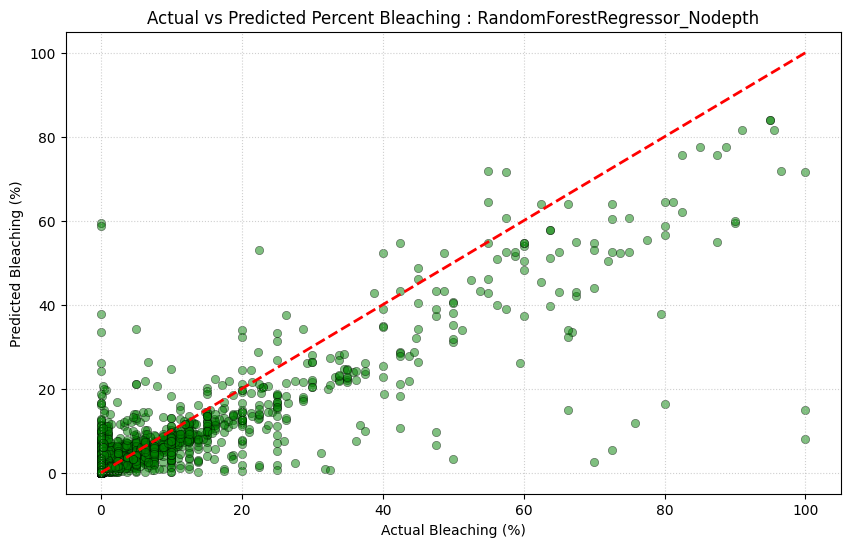


========== LGBMRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.2143
Fold MAE  : 3.4746
Fold R2   : 0.2166

===== Fold 2 / 5 =====
Fold RMSE : 8.1414
Fold MAE  : 3.4554
Fold R2   : 0.3466

===== Fold 3 / 5 =====
Fold RMSE : 7.7906
Fold MAE  : 3.3161
Fold R2   : 0.3851

===== Fold 4 / 5 =====
Fold RMSE : 7.8748
Fold MAE  : 3.3649
Fold R2   : 0.2862

===== Fold 5 / 5 =====
Fold RMSE : 6.7940
Fold MAE  : 3.2092
Fold R2   : 0.4918


Mean RMSE : 7.7630
Mean MAE  : 3.3640
Mean R2   : 0.3453


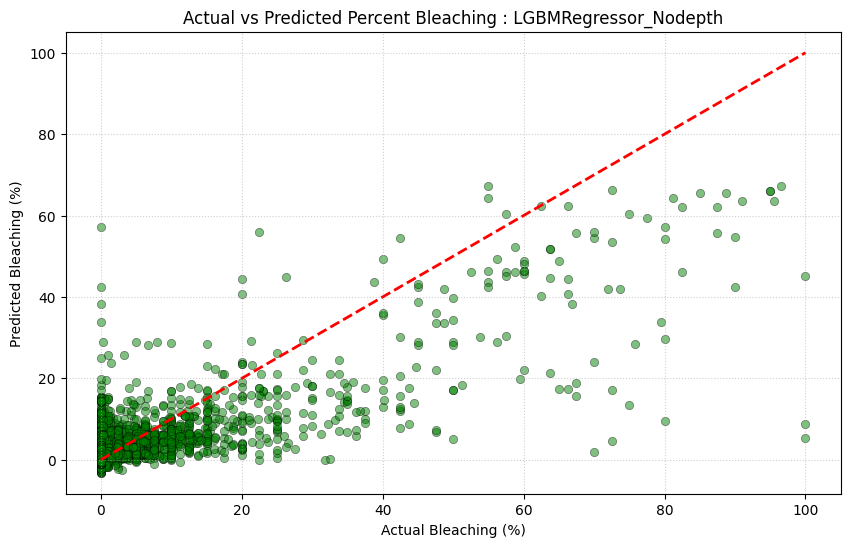


========== XGBRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.2935
Fold MAE  : 3.5019
Fold R2   : 0.2014

===== Fold 2 / 5 =====
Fold RMSE : 8.3894
Fold MAE  : 3.6274
Fold R2   : 0.3062

===== Fold 3 / 5 =====
Fold RMSE : 7.9315
Fold MAE  : 3.3572
Fold R2   : 0.3627

===== Fold 4 / 5 =====
Fold RMSE : 7.9510
Fold MAE  : 3.4483
Fold R2   : 0.2723

===== Fold 5 / 5 =====
Fold RMSE : 7.2870
Fold MAE  : 3.3484
Fold R2   : 0.4154


Mean RMSE : 7.9705
Mean MAE  : 3.4566
Mean R2   : 0.3116


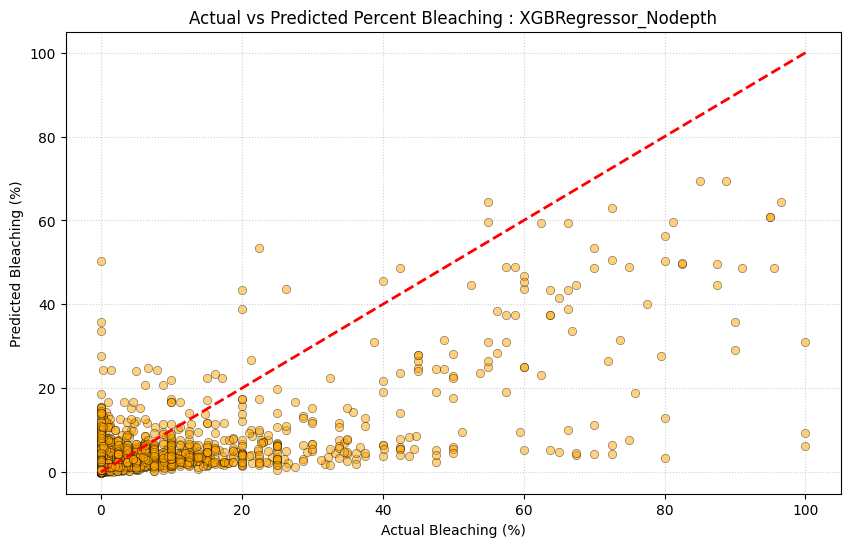


Feature Importance:
             feature  importance
1  Longitude_Degrees    0.177307
6      La_X_SSTA_DHW    0.159751
4           SSTA_DHW    0.155727
0   Latitude_Degrees    0.140464
2            ClimSST    0.133268
3               SSTA    0.119547
5          La_X_SSTA    0.113936


In [ ]:
all_results_model9th = []

for model, model_name, color in algo_model9th:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Cross_validarion_regression(
        feature_model9th.values,
        target_model9th.values,
        model,
        n_splits=5
    )

    all_results_model9th.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_model9th.values,
        y_test=target_model9th.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_model9th)
print("\nFeature Importance:")
print(feature_importance_df)

##

##

##

## model 10th : M2 + X1×X3 + X1×X6  model ของคุณ

In [ ]:
factors_interaction_F36 = ['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'SSTA', 'SSTA_DHW', 'La_X_ClimSST', 'La_X_SSTA_DHW']
feature_model10th = df_Interaction[factors_interaction_F36]
target_model10th = df_Interaction['Percent_Bleaching']

In [ ]:
X_train_model10th, X_test_model10th, y_train_model10th, y_test_model10th = train_test_split(feature_model10th.values, target_model10th.values, test_size=0.2, random_state=42)

In [ ]:
algo_model10th = [
    [RandomForestRegressor(max_features = 'sqrt', 
                           max_depth = 20, 
                           criterion = 'squared_error', 
                           n_estimators = 800, 
                           min_samples_leaf = 1,
                           min_samples_split=2,
                           random_state = 42), 'RandomForestRegressor_Nodepth', 'green'],
    
    [lgb.LGBMRegressor(colsample_bytree=0.6, 
                       learning_rate=0.01, 
                       max_depth=-1, 
                       n_estimators=1000, 
                       num_leaves=50, 
                       subsample=1.0,
                       verbose=-1,
                       random_state=42), 'LGBMRegressor_Nodepth' , 'green'],
    
    [XGBRegressor(colsample_bytree=0.6, 
                  learning_rate=0.01, 
                  max_depth=5, 
                  min_child_weight=3, 
                  n_estimators=500, 
                  subsample=0.8, 
                  gamma=0.2,
                  verbosity=0,
                  random_state=42), 'XGBRegressor_Nodepth' , 'orange']

]


========== RandomForestRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.1273
Fold MAE  : 3.1293
Fold R2   : 0.2331

===== Fold 2 / 5 =====
Fold RMSE : 7.6969
Fold MAE  : 3.1011
Fold R2   : 0.4160

===== Fold 3 / 5 =====
Fold RMSE : 7.3242
Fold MAE  : 2.8398
Fold R2   : 0.4565

===== Fold 4 / 5 =====
Fold RMSE : 7.5394
Fold MAE  : 3.0005
Fold R2   : 0.3457

===== Fold 5 / 5 =====
Fold RMSE : 6.6609
Fold MAE  : 2.9164
Fold R2   : 0.5115


Mean RMSE : 7.4697
Mean MAE  : 2.9974
Mean R2   : 0.3926


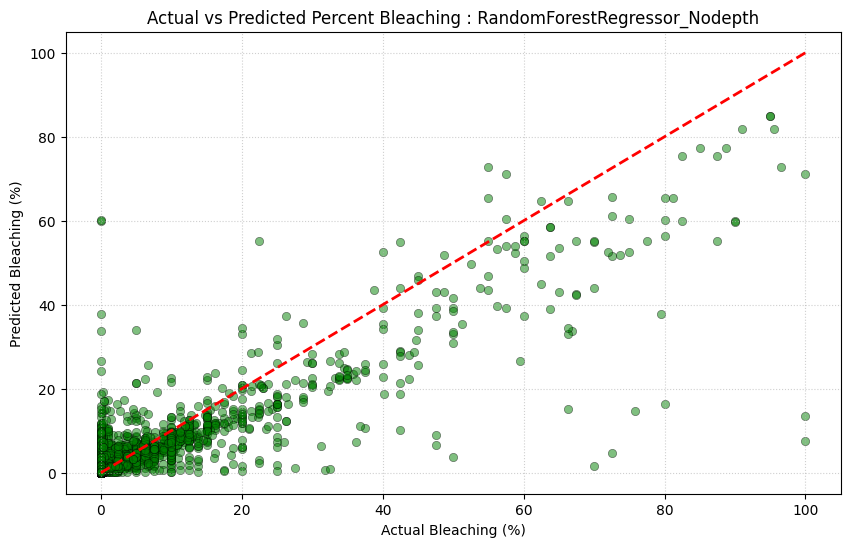


========== LGBMRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.2197
Fold MAE  : 3.4622
Fold R2   : 0.2155

===== Fold 2 / 5 =====
Fold RMSE : 8.2084
Fold MAE  : 3.4666
Fold R2   : 0.3358

===== Fold 3 / 5 =====
Fold RMSE : 7.7564
Fold MAE  : 3.2925
Fold R2   : 0.3905

===== Fold 4 / 5 =====
Fold RMSE : 7.9044
Fold MAE  : 3.3607
Fold R2   : 0.2808

===== Fold 5 / 5 =====
Fold RMSE : 6.8046
Fold MAE  : 3.1824
Fold R2   : 0.4902


Mean RMSE : 7.7787
Mean MAE  : 3.3529
Mean R2   : 0.3426


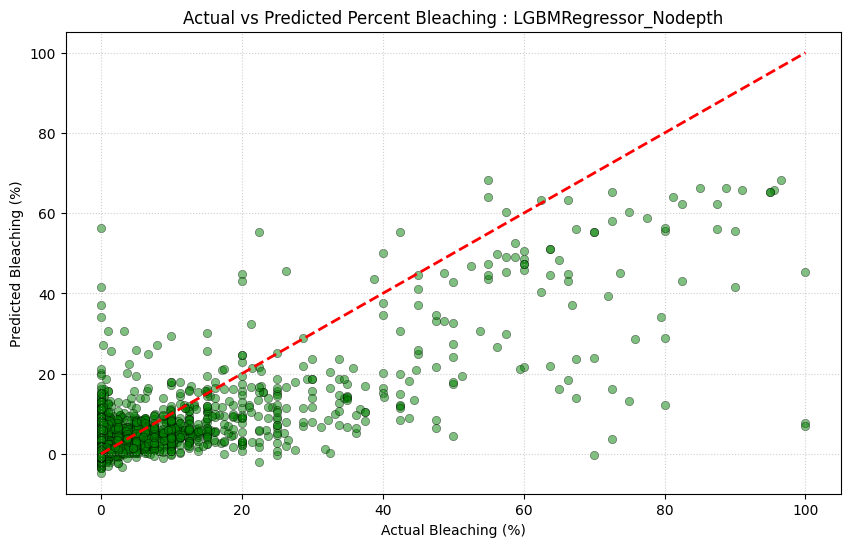


========== XGBRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.2461
Fold MAE  : 3.5104
Fold R2   : 0.2105

===== Fold 2 / 5 =====
Fold RMSE : 8.4365
Fold MAE  : 3.6507
Fold R2   : 0.2984

===== Fold 3 / 5 =====
Fold RMSE : 7.9696
Fold MAE  : 3.3424
Fold R2   : 0.3565

===== Fold 4 / 5 =====
Fold RMSE : 7.8573
Fold MAE  : 3.3856
Fold R2   : 0.2894

===== Fold 5 / 5 =====
Fold RMSE : 7.3215
Fold MAE  : 3.3459
Fold R2   : 0.4098


Mean RMSE : 7.9662
Mean MAE  : 3.4470
Mean R2   : 0.3129


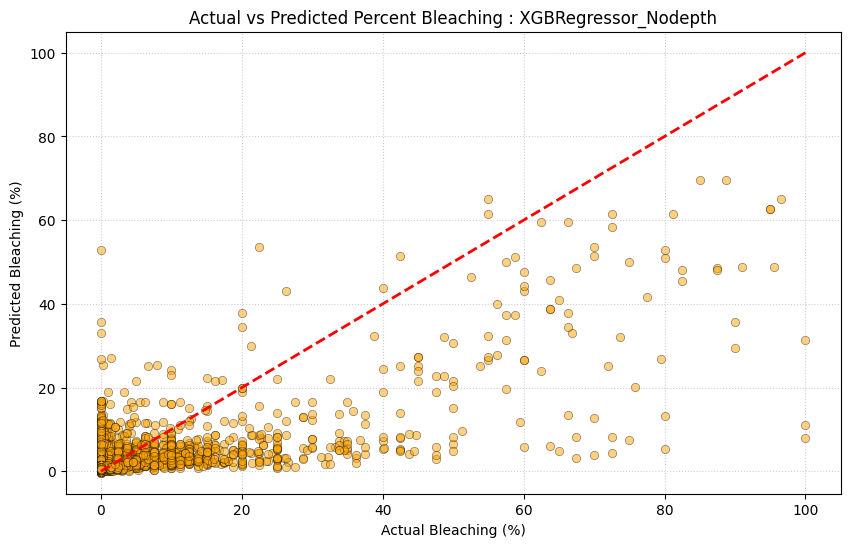


Feature Importance:
             feature  importance
1  Longitude_Degrees    0.160284
6      La_X_SSTA_DHW    0.150823
4           SSTA_DHW    0.150163
5       La_X_ClimSST    0.145646
0   Latitude_Degrees    0.139242
2            ClimSST    0.136312
3               SSTA    0.117529


In [ ]:
all_results_model10th = []

for model, model_name, color in algo_model10th:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Cross_validarion_regression(
        feature_model10th.values,
        target_model10th.values,
        model,
        n_splits=5
    )

    all_results_model10th.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_model10th.values,
        y_test=target_model10th.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_model10th)
print("\nFeature Importance:")
print(feature_importance_df)

##

##

## model 11th : X1 + X2 + X3 + X4 + X1×X2 +  X1×X3 + X1×X6  

In [ ]:
factors_interaction_11th = ['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'SSTA', 'La_X_ClimSST']
feature_model11th = df_Interaction[factors_interaction_11th]
target_model11th = df_Interaction['Percent_Bleaching']

In [ ]:
X_train_model11th, X_test_model11th, y_train_model11th, y_test_model11th = train_test_split(feature_model11th.values, target_model11th.values, test_size=0.2, random_state=42)

In [ ]:
algo_model11th = [
    [RandomForestRegressor(max_features = 'sqrt', 
                           max_depth = 20, 
                           criterion = 'squared_error', 
                           n_estimators = 800, 
                           min_samples_leaf = 1,
                           min_samples_split=2,
                           random_state = 42), 'RandomForestRegressor_Nodepth', 'green'],
    
    [lgb.LGBMRegressor(colsample_bytree=0.6, 
                       learning_rate=0.01, 
                       max_depth=-1, 
                       n_estimators=1000, 
                       num_leaves=50, 
                       subsample=1.0,
                       verbose=-1,
                       random_state=42), 'LGBMRegressor_Nodepth' , 'green'],
    
    [XGBRegressor(colsample_bytree=0.6, 
                  learning_rate=0.01, 
                  max_depth=5, 
                  min_child_weight=3, 
                  n_estimators=500, 
                  subsample=0.8, 
                  gamma=0.2,
                  verbosity=0,
                  random_state=42), 'XGBRegressor_Nodepth' , 'orange']

]


========== RandomForestRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.3707
Fold MAE  : 3.2356
Fold R2   : 0.1865

===== Fold 2 / 5 =====
Fold RMSE : 8.3747
Fold MAE  : 3.3313
Fold R2   : 0.3087

===== Fold 3 / 5 =====
Fold RMSE : 8.0213
Fold MAE  : 3.1372
Fold R2   : 0.3482

===== Fold 4 / 5 =====
Fold RMSE : 7.7972
Fold MAE  : 3.0310
Fold R2   : 0.3002

===== Fold 5 / 5 =====
Fold RMSE : 7.3260
Fold MAE  : 3.0950
Fold R2   : 0.4091


Mean RMSE : 7.9780
Mean MAE  : 3.1660
Mean R2   : 0.3105


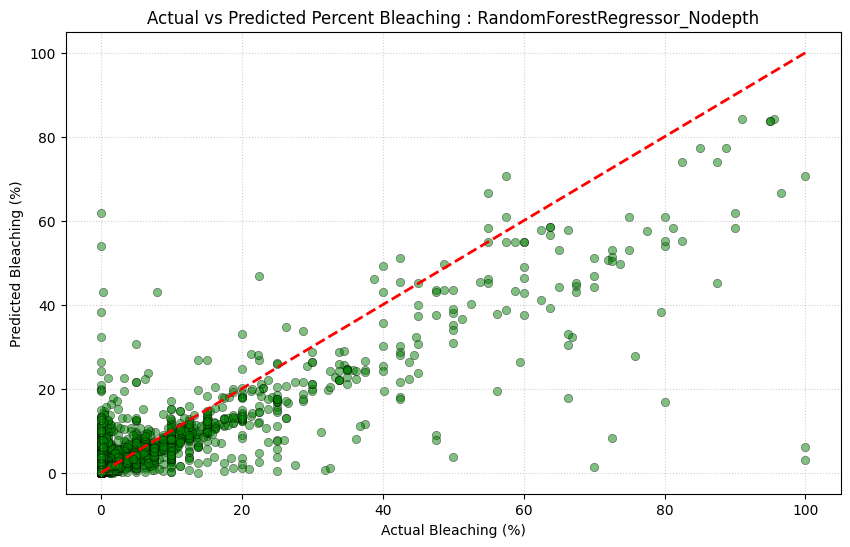


========== LGBMRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.5843
Fold MAE  : 3.7130
Fold R2   : 0.1444

===== Fold 2 / 5 =====
Fold RMSE : 8.5750
Fold MAE  : 3.7421
Fold R2   : 0.2752

===== Fold 3 / 5 =====
Fold RMSE : 8.1841
Fold MAE  : 3.4816
Fold R2   : 0.3214

===== Fold 4 / 5 =====
Fold RMSE : 8.1126
Fold MAE  : 3.5062
Fold R2   : 0.2425

===== Fold 5 / 5 =====
Fold RMSE : 7.8250
Fold MAE  : 3.5472
Fold R2   : 0.3258


Mean RMSE : 8.2562
Mean MAE  : 3.5980
Mean R2   : 0.2619


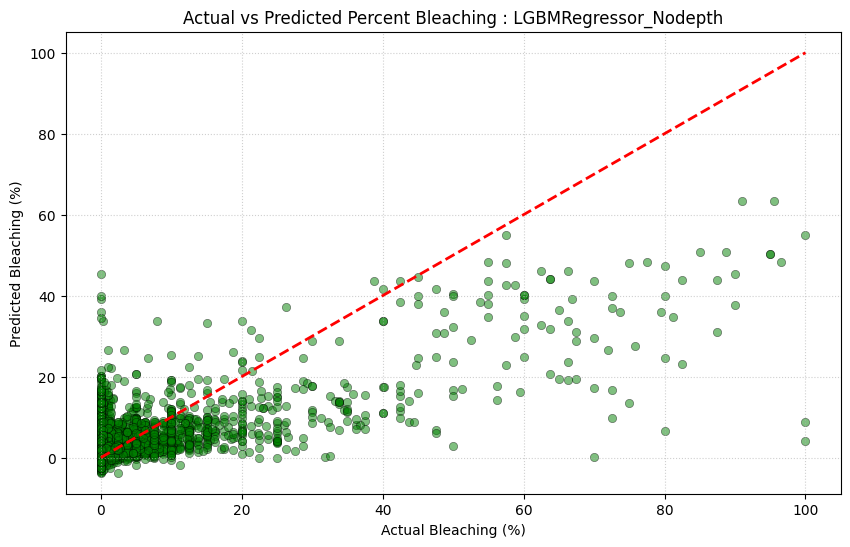


========== XGBRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.7105
Fold MAE  : 3.6393
Fold R2   : 0.1191

===== Fold 2 / 5 =====
Fold RMSE : 8.7710
Fold MAE  : 3.8290
Fold R2   : 0.2417

===== Fold 3 / 5 =====
Fold RMSE : 8.6999
Fold MAE  : 3.5932
Fold R2   : 0.2332

===== Fold 4 / 5 =====
Fold RMSE : 8.3594
Fold MAE  : 3.5523
Fold R2   : 0.1957

===== Fold 5 / 5 =====
Fold RMSE : 8.2955
Fold MAE  : 3.6678
Fold R2   : 0.2423


Mean RMSE : 8.5673
Mean MAE  : 3.6563
Mean R2   : 0.2064


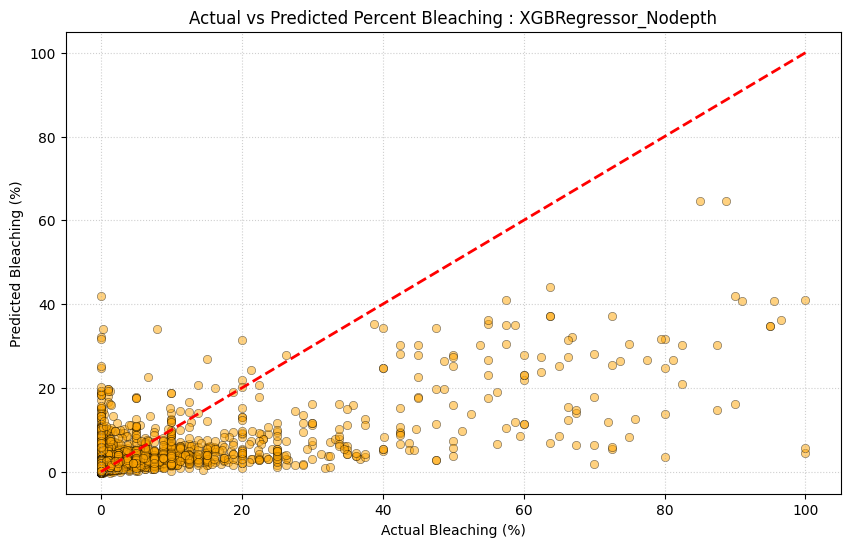


Feature Importance:
             feature  importance
4       La_X_ClimSST    0.227442
1  Longitude_Degrees    0.208637
2            ClimSST    0.205169
0   Latitude_Degrees    0.195217
3               SSTA    0.163535


In [ ]:
all_results_model11th = []

for model, model_name, color in algo_model11th:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Cross_validarion_regression(
        feature_model11th.values,
        target_model11th.values,
        model,
        n_splits=5
    )

    all_results_model11th.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_model11th.values,
        y_test=target_model11th.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_model11th)
print("\nFeature Importance:")
print(feature_importance_df)

In [ ]:
search_rf_model11th = Hyperparameter_tunning(X_train_model11th, y_train_model11th)

best_model_model11th = search_rf_model11th.best_estimator_
print("CV R²  :", search_rf_model11th.best_score_)
print("Test R²:", best_model_model11th.score(X_test_model11th, y_test_model11th))
print("best parameters:", search_rf_model11th.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
CV R²  : 0.41273818172711907
Test R²: 0.2371671159272396
best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


##

##

## model 7th : X1, X2, X3, X4, X5, X6ทดสอบว่าถ้าไม่ตัด X5 แต่เพิ่ม X6 จะเป็นอย่างไร

In [ ]:
factors_M7 = ['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'SSTA','Depth_m', 'SSTA_DHW']
feature_model7th = df_Clean_already[factors_M7]
target_model7th = df_Clean_already['Percent_Bleaching']

algo_model7th = [
    [RandomForestRegressor(max_features = 'log2', 
                           max_depth = 20, 
                           criterion = 'squared_error', 
                           n_estimators = 300, 
                           min_samples_leaf = 1,
                           min_samples_split=2,
                           random_state = 42), 'RandomForestRegressor_Nodepth', 'green'],
    
    [lgb.LGBMRegressor(colsample_bytree=0.6, 
                       learning_rate=0.01, 
                       max_depth=-1, 
                       n_estimators=1000, 
                       num_leaves=50, 
                       subsample=1.0,
                       verbose=-1,
                       random_state=42), 'LGBMRegressor_Nodepth' , 'green'],
    
    [XGBRegressor(colsample_bytree=0.6, 
                  learning_rate=0.01, 
                  max_depth=5, 
                  min_child_weight=3, 
                  n_estimators=500, 
                  subsample=0.8, 
                  gamma=0.2,
                  verbosity=0,
                  random_state=42), 'XGBRegressor_Nodepth' , 'orange']

]

In [ ]:
X_train_model7th, X_test_model7th, y_train_model7th, y_test_model7th = X_train_test_split(feature_model7th.values, target_model7th.values)


========== RandomForestRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.0003
Fold MAE  : 3.2345
Fold R2   : 0.2569

===== Fold 2 / 5 =====
Fold RMSE : 7.6660
Fold MAE  : 3.2170
Fold R2   : 0.4207

===== Fold 3 / 5 =====
Fold RMSE : 7.5605
Fold MAE  : 3.0818
Fold R2   : 0.4209

===== Fold 4 / 5 =====
Fold RMSE : 7.7542
Fold MAE  : 3.1908
Fold R2   : 0.3079

===== Fold 5 / 5 =====
Fold RMSE : 6.8626
Fold MAE  : 3.1088
Fold R2   : 0.4815


Mean RMSE : 7.5687
Mean MAE  : 3.1666
Mean R2   : 0.3776


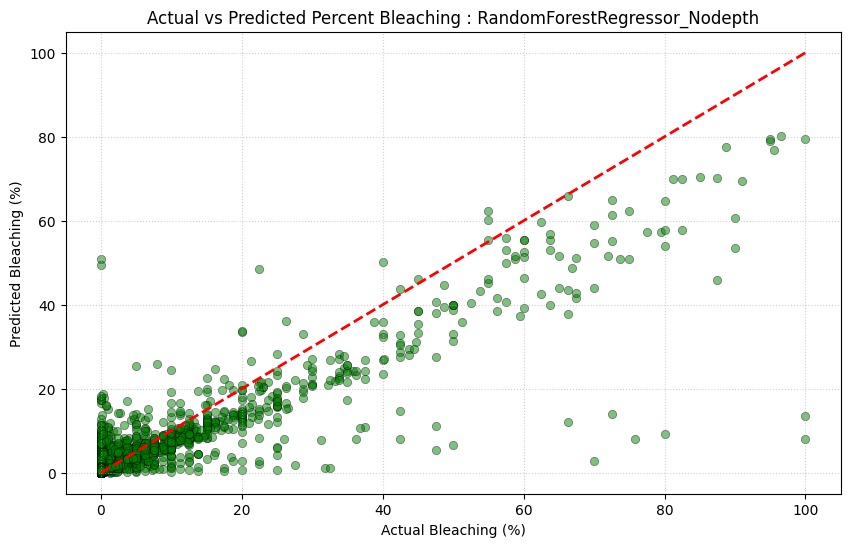


========== LGBMRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.2325
Fold MAE  : 3.5837
Fold R2   : 0.2131

===== Fold 2 / 5 =====
Fold RMSE : 8.1325
Fold MAE  : 3.5113
Fold R2   : 0.3481

===== Fold 3 / 5 =====
Fold RMSE : 7.9241
Fold MAE  : 3.4525
Fold R2   : 0.3639

===== Fold 4 / 5 =====
Fold RMSE : 8.0390
Fold MAE  : 3.4327
Fold R2   : 0.2561

===== Fold 5 / 5 =====
Fold RMSE : 7.0386
Fold MAE  : 3.3664
Fold R2   : 0.4545


Mean RMSE : 7.8734
Mean MAE  : 3.4693
Mean R2   : 0.3271


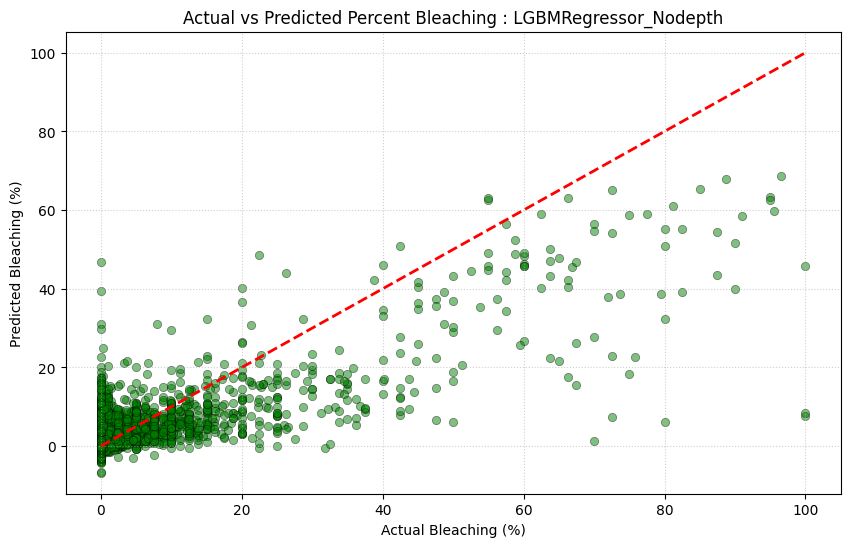


========== XGBRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 8.3934
Fold MAE  : 3.5780
Fold R2   : 0.1820

===== Fold 2 / 5 =====
Fold RMSE : 8.5724
Fold MAE  : 3.6767
Fold R2   : 0.2756

===== Fold 3 / 5 =====
Fold RMSE : 8.3293
Fold MAE  : 3.5313
Fold R2   : 0.2971

===== Fold 4 / 5 =====
Fold RMSE : 8.1926
Fold MAE  : 3.5036
Fold R2   : 0.2274

===== Fold 5 / 5 =====
Fold RMSE : 7.7643
Fold MAE  : 3.5255
Fold R2   : 0.3363


Mean RMSE : 8.2504
Mean MAE  : 3.5630
Mean R2   : 0.2637


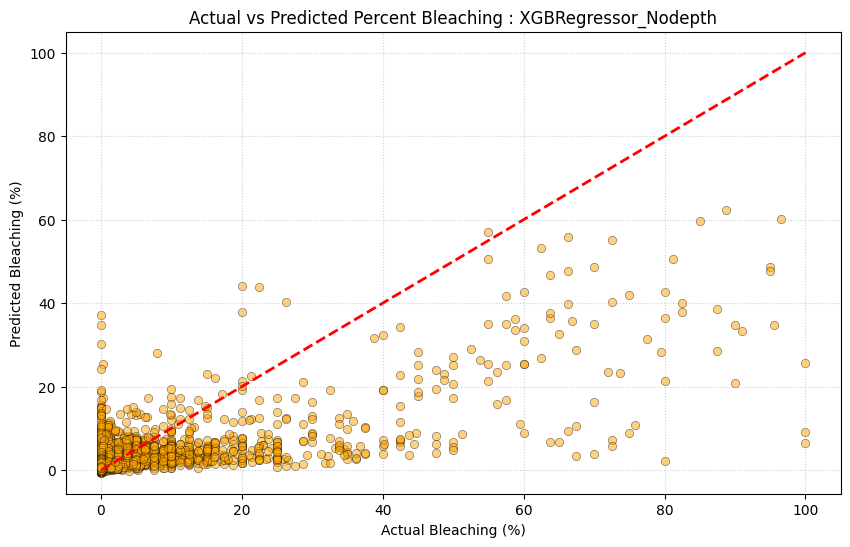


Feature Importance:
             feature  importance
5           SSTA_DHW    0.218896
0   Latitude_Degrees    0.205585
1  Longitude_Degrees    0.199313
2            ClimSST    0.164749
3               SSTA    0.137618
4            Depth_m    0.073840


In [ ]:
all_results_model7th = []

for model, model_name, color in algo_model7th:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Cross_validarion_regression(
        feature_model7th.values,
        target_model7th.values,
        model,
        n_splits=5
    )

    all_results_model7th.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_model7th.values,
        y_test=target_model7th.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_model7th)
print("\nFeature Importance:")
print(feature_importance_df)

In [ ]:
search_rf_model7th = Hyperparameter_tunning(X_train_model7th, y_train_model7th)

best_model_model7th = search_rf_model7th.best_estimator_
print("CV R²  :", search_rf_model7th.best_score_)
print("Test R²:", best_model_model7th.score(X_test_model7th, y_test_model7th))
print("best parameters:", search_rf_model7th.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
CV R²  : 0.38457410816802173
Test R²: 0.24842185158394725
best parameters: {'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}


##

##

## Special Experimental : Discovered feature to helping model capture high bleaching 

In [ ]:
df_Special_model = df_Interaction.copy()

In [ ]:
df_high_bleaching = df_Special_model[df_Special_model['Percent_Bleaching'] > 20]
feature_high_bleaching = df_high_bleaching[['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'SSTA', 'SSTA_DHW', 'La_X_SSTA', 'La_X_SSTA_DHW', 'La_X_ClimSST', 'Depth_m']]
target_high_bleaching = df_high_bleaching[['Percent_Bleaching']]

In [ ]:
feature_high_bleaching

,Latitude_Degrees,Longitude_Degrees,ClimSST,SSTA,SSTA_DHW,La_X_SSTA,La_X_SSTA_DHW,La_X_ClimSST,Depth_m
3,-20.737694,149.464944,298.21,1.070000,3.650000,-22.189333,-75.692585,-6184.187859,5.0
5,-20.252556,148.812917,296.48,1.760000,3.840000,-35.644498,-77.769813,-6004.477672,2.0
7,-20.039000,148.875833,296.79,0.430000,7.370000,-8.616770,-147.687430,-5947.374810,4.0
12,-19.745778,149.165944,298.51,0.060000,18.300000,-1.184747,-361.347733,-5894.312125,5.0
18,-19.198333,146.815167,295.29,1.710000,14.390000,-32.829150,-276.264017,-5669.075849,3.0
...,...,...,...,...,...,...,...,...,...
9333,26.205306,-80.085111,262.15,0.693333,0.856667,18.169012,22.449212,6869.720853,6.7
9342,26.244889,-80.066639,302.57,0.390000,6.270000,10.235507,164.555453,7940.916031,15.5
9355,26.695583,-80.018139,302.35,0.530000,2.100000,14.148659,56.060725,8071.409620,16.0
9357,27.121167,-80.127806,301.76,1.050000,3.800000,28.477225,103.060433,8184.083254,7.0


In [ ]:
algo_Special = [
    [RandomForestRegressor(max_features = 'sqrt', 
                           max_depth = 20, 
                           criterion = 'squared_error', 
                           n_estimators = 500, 
                           min_samples_leaf = 1,
                           min_samples_split=2,
                           random_state = 42), 'RandomForestRegressor_Nodepth', 'green'],
    
    [lgb.LGBMRegressor(colsample_bytree=0.6, 
                       learning_rate=0.01, 
                       max_depth=-1, 
                       n_estimators=1000, 
                       num_leaves=50, 
                       subsample=1.0,
                       verbose=-1,
                       random_state=42), 'LGBMRegressor_Nodepth' , 'green'],
    
    [XGBRegressor(colsample_bytree=0.6, 
                  learning_rate=0.01, 
                  max_depth=5, 
                  min_child_weight=3, 
                  n_estimators=500, 
                  subsample=0.8, 
                  gamma=0.2,
                  verbosity=0,
                  random_state=42), 'XGBRegressor_Nodepth' , 'orange']

]


========== RandomForestRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 22.0126
Fold MAE  : 17.6672
Fold R2   : 0.2239

===== Fold 2 / 5 =====
Fold RMSE : 21.3189
Fold MAE  : 17.3331
Fold R2   : -0.1577

===== Fold 3 / 5 =====
Fold RMSE : 17.3192
Fold MAE  : 14.2115
Fold R2   : 0.3453

===== Fold 4 / 5 =====
Fold RMSE : 15.6918
Fold MAE  : 13.1603
Fold R2   : 0.2065

===== Fold 5 / 5 =====
Fold RMSE : 18.3074
Fold MAE  : 14.8037
Fold R2   : 0.1351


Mean RMSE : 18.9300
Mean MAE  : 15.4352
Mean R2   : 0.1506


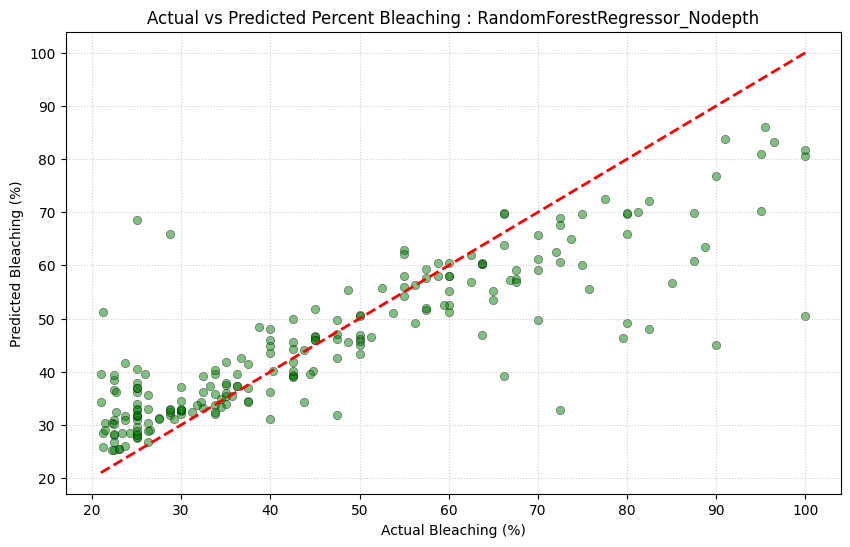


========== LGBMRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 22.9725
Fold MAE  : 18.8302
Fold R2   : 0.1548

===== Fold 2 / 5 =====
Fold RMSE : 22.0072
Fold MAE  : 17.6019
Fold R2   : -0.2337

===== Fold 3 / 5 =====
Fold RMSE : 18.9238
Fold MAE  : 15.2608
Fold R2   : 0.2183

===== Fold 4 / 5 =====
Fold RMSE : 16.8045
Fold MAE  : 13.4318
Fold R2   : 0.0900

===== Fold 5 / 5 =====
Fold RMSE : 18.4138
Fold MAE  : 15.1320
Fold R2   : 0.1250


Mean RMSE : 19.8244
Mean MAE  : 16.0513
Mean R2   : 0.0709


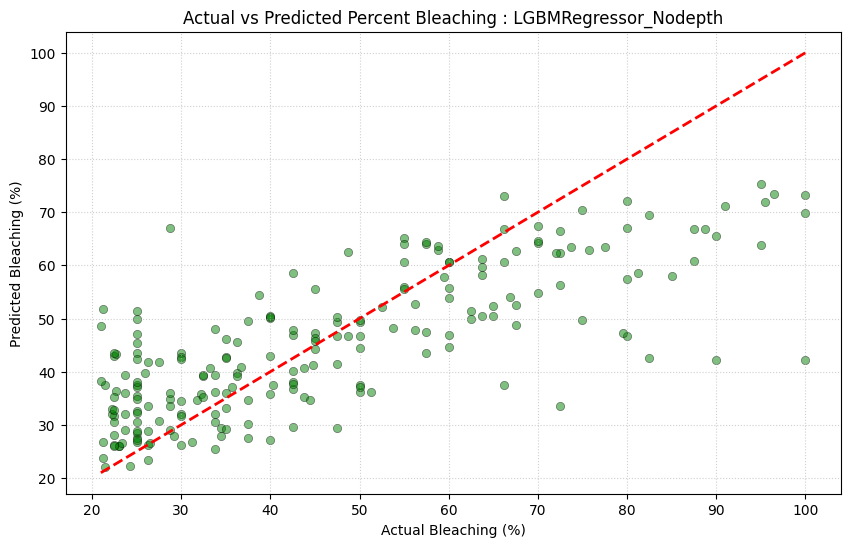


========== XGBRegressor_Nodepth ==========

===== Fold 1 / 5 =====
Fold RMSE : 22.7827
Fold MAE  : 18.0031
Fold R2   : 0.1687

===== Fold 2 / 5 =====
Fold RMSE : 20.8610
Fold MAE  : 16.4480
Fold R2   : -0.1085

===== Fold 3 / 5 =====
Fold RMSE : 18.1266
Fold MAE  : 14.3793
Fold R2   : 0.2828

===== Fold 4 / 5 =====
Fold RMSE : 16.7073
Fold MAE  : 13.6699
Fold R2   : 0.1005

===== Fold 5 / 5 =====
Fold RMSE : 18.6836
Fold MAE  : 14.8662
Fold R2   : 0.0991


Mean RMSE : 19.4322
Mean MAE  : 15.4733
Mean R2   : 0.1085


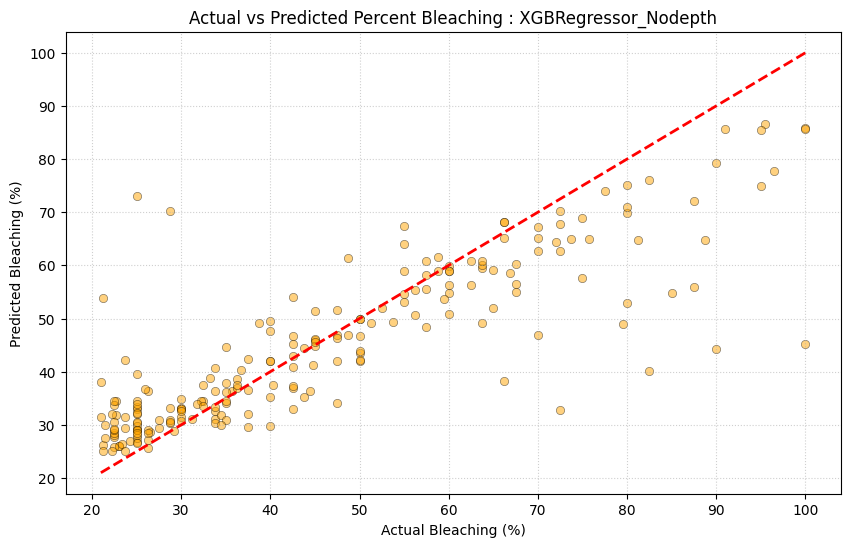


Feature Importance:
             feature  importance
7       La_X_ClimSST    0.148764
6      La_X_SSTA_DHW    0.141281
4           SSTA_DHW    0.135951
1  Longitude_Degrees    0.110583
0   Latitude_Degrees    0.102623
3               SSTA    0.095537
2            ClimSST    0.093107
8            Depth_m    0.087113
5          La_X_SSTA    0.085040


In [ ]:
all_results_Special = []

for model, model_name, color in algo_Special:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Cross_validarion_regression(
        feature_high_bleaching.values,
        target_high_bleaching.values,
        model,
        n_splits=5
    )

    all_results_Special.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })
    
    PLOTING_RESULT_ML(
        models[0],
        X_test=feature_high_bleaching.values,
        y_test=target_high_bleaching.values,
        cl=color,
        name=model_name
    )
    
feature_importance_df = feature_importance(models[0], feature_high_bleaching)
print("\nFeature Importance:")
print(feature_importance_df)